# Проект предсказания вероятности отмены доставки заказа CargaPronto


Логистическая компания по доставке товаров CargaPronto выявила проблему в своем бизнесе, заключающуюся в том что 55% заказов доставляется с опозданием. Для решения данной проблемы необходимо разработать модель машинного обучения, предсказывающую вероятность отмены доставки заказа для внедрения в системе принятия решений операторами службы доставки.

## Содержание
1. <a href="#business_ml">Постановка задачи</a>
1. <a href="#libraries">Импорт библиотек, выполнение базовых настроек</a>
1. <a href="#data_load">Загрузка данных, первичное знакомство</a>
1. <a href="#eda">EDA</a>
1. <a href="#split">Разделение на выборки</a>
1. <a href="#baseline">Обучение базовой модели</a>
1. <a href="#geo_cluster">Кластеризация по признакам, связанным с местоположением</a>
1. <a href="#beh_cluster">Кластеризация по признакам профилей клиентов</a>
1. <a href="#enhanced_model">Обучение модели на новых признаках</a>
1. <a href="#extra">Дополнительное задание — подбор лучшего количества кластеров</a>
1. <a href="#test">Тестирование лучшей модели</a>
1. <a href="#conclusion">Выводы и рекомендации</a>


<a id="business_ml"></a>

## Постановка задачи

На языке машинного обучения решается задача бинарной классификации, при этом модель должна возвращать вероятность принадлежности к каждому классу:
- 0 — доставка выполнена в срок, задержки не было
- 1 — доставка задержана (late_delivery_risk = 1)

Задача относится к классу обучения с учителем, так как в исходных данных присутствует целевая переменная late_delivery_risk.

**Признаки и Feature Engineering**
Помимо стандартных числовых и категориальных признаков (режим доставки, категория товара, цена, временные характеристики заказа), в качестве ключевой гипотезы проекта проверяется следующее:

> Профиль клиента и его географическое положение несут дополнительную предсказательную силу, которую нельзя извлечь из характеристик отдельного заказа напрямую.

Для проверки этой гипотезы применяется двухуровневая кластеризация:

- Географическая сегментация — алгоритм KMeans++ разбивает клиентов на логистические зоны по координатам (customer_lat, customer_lon), формируя признак geo_cluster. Предположение состоит в том, что задержки распределены неравномерно по территории: одни зоны обслуживаются надёжнее, другие — системно хуже.

- Поведенческая сегментация (RFM) — клиенты группируются по пяти показателям активности и благонадёжности: давности последнего заказа (recency), частоте (total_orders = Frequency), суммарной выручке (total_sales = Monytary), доле проблемных заказов (return_rate) и среднему размеру скидки (avg_discount). Результат записывается в признак beh_cluster. Предположение состоит в том, что поведенческий профиль клиента коррелирует с риском задержки — например, клиенты с высоким return_rate чаще сталкиваются с логистическими проблемами.


**Модели**

В качестве основного алгоритма используется CatBoostClassifier — как хорошо зарекомендовавшая себя модель, встроенной поддержкой категориальных признаков и низкой склонностью к переобучению. В качестве дополнительного алгоритма используется LogisticRegression — как интерпретируемая линейная базовая модель, позволяющая оценить, насколько зависимости в данных поддаются линейному описанию.

Обе модели обучаются дважды: на базовом наборе признаков (только характеристики заказа) и на расширенном наборе (с добавлением geo_cluster и beh_cluster). Это позволяет количественно оценить вклад кластеризации в качество прогноза.

**Метрики оценки**

Модель оценивается по метрике ROC-AUC как основной, поскольку она устойчива к дисбалансу классов и отражает способность модели ранжировать заказы по вероятности задержки. Дополнительно анализируются стандартные метрики классификации: Precision, Recall и F1-score.


**Модель считается успешной при выполнении следующего условия:**

- ROC-AUC на тестовой выборке ≥ 0.75
- Дополнительным критерием служит положительный прирост ROC-AUC расширенной модели (с кластерами) по сравнению с базовой (без кластеров) — это будет означать, что гипотеза о влиянии профиля клиента и географии на риск задержки подтверждена.

<a id="libraries"></a>

##  Импорт библиотек, выполнение базовых настроек

In [1]:
! rm requirements.txt
! python --version

Python 3.12.9


In [2]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
    'optuna==4.8.0',
    'humanfriendly==10.0',
    'phik==0.12.5',
    'catboost==1.2.10',
    'contextily==1.7.0',
    'shap==0.49.1',
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Установка зависимостей...')
!pip install -r requirements.txt
print('Зависимости успешно установлены!')


requirements.txt created
Установка зависимостей...
Зависимости успешно установлены!


Импорт классов и методов

In [3]:
import os
import requests
import optuna
import time
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
from IPython.display import display
from phik import phik_matrix

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from humanfriendly import format_size


/Users/ngsmirnov/nikki/projects/practicum/sprint18_catboost_clasterization_bin_classif/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка библиотеки классов SoloNeiroGood

Персональная библиотека для решения задач DS за авторством Smirnov Nikolai Georgievich (c) 2026-2027

In [4]:
TARGET_COL_NAME = 'late_delivery_risk'
RANDOM_STATE = 42
NAN_FLOAT = -999999.0
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке


class DataBaseEnvConfig:
    """
    Класс для конфигурации подключения к БД через переменные окружения
    """
    def get_engine(self):
        load_dotenv()
        connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
            os.getenv('DB_USER'),
            os.getenv('DB_PASSWORD'),
            os.getenv('DB_HOST'),
            os.getenv('DB_PORT'),
            os.getenv('DB_NAME')
        )
        return create_engine(connection_string)


#### Заргузка ресурсов
class ResourceLoader:
    """
    Класс для безопасной загрузки ресурсов по http или с помощью подключения к БД.
    По http можно загружать как датасет в формате CSV, так и прозвольный файл.
    Если файл уже был скачан ранее и сохранен в локальной файловой системе, то
    загрузка из удаленного источника не производится.

    Для загрузки датасета: load_dataset(dataset_url, local_file, local_path='datasets'): dataframe
    Для загрузки файла: load_resource(resource_url, local_path, local_file): path
    """

    def __init__(self):
        pass

    def load_dataset_sql(self, table_name, local_path='datasets', query=None):
        """
        Загрузка датасета из БД по SQL запросу
        """
        local_dataset = f'{local_path}/{table_name}.csv'

        if os.path.exists(local_dataset):
            df = pd.read_csv(local_dataset)
            print(f'Датасет загружен из локального файла {local_dataset} без подключений к БД')
        else:
            if query is None:
                query = f'SELECT * FROM {table_name}'
            print(f'Загружаем датасет из БД по SQL запросу: {query[:30]}...')
            load_dotenv()
            df = pd.read_sql_query(query, con=DataBaseEnvConfig().get_engine())
            # сохраним датасет локально, чтобы не загружать из файла при рестарте ноутбука
            os.makedirs(local_path, exist_ok=True)
            df.to_csv(local_dataset, index=False)
            df = pd.read_csv(local_dataset)
            file_size = format_size(os.path.getsize(local_dataset))
            print(f'Датасет успешно загружен в {local_dataset},',
                  f'размер файла: {file_size}')
        return df

    def load_resource(self, resource_url, local_path, local_file):
        """
        Загрузка произвольного файла из сети и сохраение его локально.
        Если файл уже существует локально, то загрузка не происходит
        """
        local_resource_file = f'{local_path}/{local_file}'
        if os.path.exists(local_resource_file):
            print(f'Файл {local_resource_file} уже существует')
            return local_resource_file

        os.makedirs(local_path, exist_ok=True)
        print(f'Загружаем файл из {resource_url}')
        response = requests.get(resource_url)
        if response.status_code == 200:
            with open(local_resource_file, 'wb') as f:
                f.write(response.content)
            file_size = format_size(os.path.getsize(local_resource_file))
            print(f'Файл успешно загружен в {local_resource_file},',
                  f'размер файла: {file_size}')
            return local_resource_file
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')


    def load_dataset(
        self,
        dataset_url,
        local_file = None,
        local_path='datasets',
        sep=',',
        decimal='.'
    ):
        """
        Специальный. метод загрузки датасета по сети. Если датасет уже был скачан ранее и
        сохранен в локальной файловой системе, то загрузка не происходит.

        Parameters:
            dataset_url: str - url датасета
            local_file: str - имя файла, куда будет сохранен датасет (если None - будет вычислен из URL)
            local_path: str - путь к папке, куда будет сохранен датасет
            sep: str - разделитель в файле CSV
            decimal: str - символ, разделяющий целую часть от дробной в CSV

        Returns:
            df: pd.DataFrame - датасет
        """
        if local_file is None:
            local_file = dataset_url.split('/')[-1]
        local_dataset_file = f'{local_path}/{local_file}'
        remote_dataset_url = dataset_url
        def read_dataset_csv():
            return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

        try:
            df = read_dataset_csv()
            print(f'Датасет успешно загружен из {local_dataset_file}')
        except FileNotFoundError:
            self.load_resource(remote_dataset_url, local_path, local_file)
            df = read_dataset_csv()

        print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
        return df

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        """
        Возвращает матрицу корреляций признаков, переданную в конструкторе
        """
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
        self,
        digits=2,
        title='Матрица корреляций признаков',
        subtitle=None,
        figsize=(16, 10),
        subset=None,
    ):
        """
        Отображает полную матрицу корреляций признаков в виде heatmap

        Parameters:
            digits: int - количество знаков после запятой в значениях heatmap
            subset: [] - модмножество столбцов кор.матрицы для отображения
        """
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix, fmt=f'.{digits}f', annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        """
        Отображает матрицу корреляций признаков с таргетом в виде вертикального heatmap

        Parameters:
            target_col: str - название столбца таргета
            title: str - заголовок графика
            subtitle: str - подзаголовок графика
        """
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        """
        Отображает попарные корреляции признаков в виде вертикального heatmap

        Parameters:
            subset: [] - модмножество столбцов кор.матрицы для отображения
            figsize: (int, int) - размер графика
            corr_threshold: float - порог корреляции, ниже которого корреляция не будет отображена
        """
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

class EDAHelper:
    """
    Класс для выполнения Exploratory Data Analysis (EDA)
    """
    def __init__(self):
        pass

    def df_info(self, df, name = '', n_samples=3):
        """
        Выводит информацию о датасете:
        - количество строк и столбцов
        - размер датасета в памяти
        - первые, случайные и последние n_samples строк
        - информацию о типах данных столбцов
        - информацию о пропущенных значениях и проценте пропущенных значений в каждом столбце

        Parameters:
            df: pd.DataFrame - датафрейм
            name: str - произвольное название датасета
            n_samples: int - количество строк для вывода объектов датасета из начала, середины и конца
        """
        print('-'*50)
        print(f'Описание датасета {name}:')
        print(f'Датасет {name} содержит {df.shape[0]} строк и {df.shape[1]} столбцов.')
        print(f'Размер датасета {name} в памяти: {format_size(df.memory_usage().sum())}')
        print('-'*50)
        print(f'Данные датасета {name}:')
        print('-'*50)
        sample_df =  pd.concat([
            df.head(n_samples).assign(place='head'),
            df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
            df.tail(n_samples).assign(place='tail'),
        ]).sort_index()
        # move place column to first place
        last_col = sample_df.pop(sample_df.columns[-1])
        sample_df.insert(0, last_col.name, last_col)
        display(sample_df)
        print('-'*50)

        print(df.info())
        nan_counts = self.na_info(df)
        if (len(nan_counts) > 0):
            display(nan_counts)
        else:
            print(f'В датасете {name} нет пропущенных значений')

    def convert_to_datetime(self, df, column, format='%Y-%m-%d', print_time_range=True):
        """
        Преобразует столбец в датафрейме в дату и отображает временную ось данных в столбце
        Parameters:
            df: pd.DataFrame - датафрейм
            column: str - название столбца
            format: str - формат даты
            print_time_range: bool - выводить ли временной диапазон данных в столбце
        """
        df[column] = pd.to_datetime(df[column], format=format)
        if print_time_range:
            self.print_time_range(df, column)
        return df


    def print_time_range(self, df, datetime_column):
        """
        Выводит временную ось данных в столбце
        Parameters:
            df: pd.DataFrame - датафрейм
            datetime_column: str - название столбца
        """
        # определим временную ось таблицы:
        start_date = df[datetime_column].min()
        end_date = df[datetime_column].max()
        diff = int((end_date - start_date) / np.timedelta64(1, 'D'))
        diff_years = diff / 365.25

        print(f'Данные в "{datetime_column}" представлены за период {diff} дн. ({diff_years:.1f} л.): {start_date} - {end_date}')

    def value_counts(self, df, column, normalize=False, title=None,
                 vertical=True, rot=0, hue=None, grid=True, show_data=True, figsize=None):
        """
        Выводит bar plot для каждого значения в столбце column,
        где размер графика зависит от количества объектов с данным значением
        Parameters:
            df: pd.DataFrame - датафрейм
            column: str - название столбца
            normalize: bool - нормализовать ли количество значений
            title: str - заголовок графика
            vertical: bool - вертикальный график
            rot: int - угол поворота подписей оси X
            hue: str - название столбца для группировки
            grid: bool - добавить ли сетку
            show_data: bool - выводить ли исходные данные
        """
        # --- Агрегация ---
        if hue:
            data = (
                df.groupby([column, hue])
                .size()
                .reset_index(name="count_or_share")
            )
            if normalize:
                total = data.groupby(hue)["count_or_share"].transform("sum")
                data["count_or_share"] = data["count_or_share"] / total
        else:
            data = (
                df[column]
                .value_counts(normalize=normalize)
                .rename("count_or_share")
                .reset_index()
            )

        # --- Сортировка для горизонтального графика ---
        if not vertical:
            if hue:
                order = (
                    data.groupby(column)["count_or_share"]
                    .sum()
                    .sort_values()
                    .index.tolist()
                )
            else:
                data = data.sort_values(by="count_or_share", ascending=False)
                order = None
        else:
            order = None

        # --- Подписи ---
        metric_label = "Доля внутри группы" if normalize else "Количество объектов"

        # --- Маппинг осей ---
        if hue:
            plot_axes = (
                {"x": column, "y": "count_or_share", "hue": hue}  # column на ось X, hue как цвет
                if vertical
                else {"x": "count_or_share", "y": column, "hue": hue}
            )
        else:
            plot_axes = (
                {"x": column, "y": "count_or_share"}
                if vertical
                else {"x": "count_or_share", "y": column}
            )

        # --- Визуализация ---
        with sns.axes_style("whitegrid" if grid else "white"):
            fig, ax = plt.subplots(figsize=figsize)
            sns.barplot(
                data=data,
                orient="v" if vertical else "h",
                ax=ax,
                order=order,
                **plot_axes,
            )

        ax.set_xlabel(column if vertical else metric_label)
        ax.set_ylabel(metric_label if vertical else column)
        ax.tick_params(axis="x" if vertical else "y", labelrotation=rot)
        ax.set_title(
            title if title
            else f'{"Доля" if normalize else "Количество"} значений {column}'
        )

        plt.tight_layout()
        plt.show()

        if show_data:
            display(data)



    def box_hist(self, df, column, title=None, bins='auto', hue=None, kde=True, stat='density'):
        """
        Выводит boxplot и histogramm для столбца датасета на одном графике
        Parameters:
            df: pd.DataFrame - датафрейм
            column: str - название столбца
            title: str - заголовок графика
            bins: int|'auto' - количество бинов в гистограмме
            hue: str - название столбца для разбивки гистограммы по категориям
            kde: bool - рисовать ли kernel density estimation (плотность распределения)
            stat: str - тип значения для оси Y:
                - 'density' - плотность распределения (Normalizes the bars so that the total area
                    of the histogram equals 1. This is ideal when comparing your histogram
                    to a continuous Probability Density
                - 'count' - количество объектов
                - 'frequency' - частота (Shows the number of observations divided by the bin width,
                    which accounts for bins of varying sizes)
                - 'probability' или 'proportion' - пропорция (Normalizes the counts so that the
                    height of all bars sums to 1. Useful for comparing relative contributions to a whole)
                - 'percent' - процент от всего датасета
        """
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        display(pd.DataFrame(df[[column]].describe().T))
        sns.boxplot(df[column], orient='h', ax=ax_box)
        sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=kde, stat=stat)

        f.suptitle(f'Распределение признака {column}' if title is None else title)
        if stat == 'density':
            ylabel = 'Плотность распределения'
        elif stat == 'count':
            ylabel = 'Количество'
        elif stat == 'frequency':
            ylabel = 'Частота'
        elif stat == 'probability' or stat == 'proportion':
            ylabel = 'Доля'
        elif stat == 'percent':
            ylabel = 'Процент от общего числа'
        else:
            ylabel = 'Доля'

        ax_box.set(xlabel='')
        ax_hist.set(
            xlabel=f'Значения признака {column}',
            ylabel=ylabel
        )
        plt.show()

    def time_line(self, df, datetime_column, y_column, ylabel=None, plot_kwargs={}):
        """
        Выводит значение признака y_column на временной оси datetime_column
        Parameters:
            df: pd.DataFrame - датафрейм
            datetime_column: str - название столбца со временной осью
            y_column: str - название столбца для отображения по оси Y
            ylabel: str - подпись оси Y
        """
        if ylabel is None:
            ylabel = y_column

        params = {
            'kind': 'line',
            'x': datetime_column,
            'y': y_column,
            'xlabel': 'Дата',
            'ylabel': ylabel,
            'title': f'Завимость признака "{y_column}" от времени',
            'legend': False,
        } | plot_kwargs
        df.plot(
            **params
        )
        plt.show()

    def drop_duplicates(self, df, subset=None):
        """
        Удаляет дубликаты из датасета и иценивает их количество и процент от датасета
        Parameters:
            df: pd.DataFrame - датафрейм
            subset: list - список столбцов, по которым проверять дубликаты
        """
        ndups = df.duplicated(subset=subset).sum()
        print(f'Найдено {ndups} дубликатов по {"всем" if subset is None else subset} столбцам')
        if ndups > 0:
            df_orig = df.copy()
            df.drop_duplicates(subset=subset, inplace=True)
            diff = len(df_orig) - len(df)
            diff_pct = diff / len(df_orig) * 100
            print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
        else:
            print('Дубликатов не обнаружено')

    def na_info(self, df, round_digits=1):
        '''
        Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
        '''
        count_na_name = 'Количество пропусков'
        res = pd.DataFrame({
            'Количество строк': len(df),
            count_na_name: df.isna().sum(),
            'Процент пропусков': round(df.isna().mean()*100, round_digits)
        }).sort_values(by=count_na_name, ascending=False)
        return res.query(f'`{count_na_name}` > 0').reset_index()


    # Уникальные значения всех категориальных признаков
    def get_unique_values(self, df, top_n=5, cat_columns=[]):
        """
        Возвращает таблицу с уникальными значениями всех категориальных признаков.
        Parameters:
            df: pd.DataFrame - датафрейм
            top_n: int - количество значений для вывода высококардинальных столбцов
            cat_columns: list - список категориальных признаков, если не передан,
            то берутся все категориальные признаки с типом object
        """
        print('Уникальные значения всех категориальных признаков:\n')
        data = []
        columns = cat_columns if cat_columns else df.select_dtypes(include=['object']).columns
        for col in columns:
            unique_vals = df[col].unique().tolist()
            unique_vals.sort()
            top_n_vals = ', '.join(unique_vals[:top_n])
            unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
            num_of_unique_vals = df[col].nunique()
            data.append({
                'feature': col,
                'num_of_unique_vals': num_of_unique_vals,
                'unique_vals': unique_val_str,
            })
        return pd.DataFrame(data)

### Обучение модели
class ModelTrainHelper:
    """
    Класс с утилитарными функциями для обучения и оценки качества модели МО
    """
    def __init__(self):
        self.best_estimator_ = None
        pass

    def do_cross_validation(
            self,
            pipelines,
            X_train_val, y_train_val,
            scoring,
            metrics_df_list = [],
            return_train_score=False,
            cv=5,
    ):
        """
        Выполняет обучение модели с помощью кросс-валидации.
        Parameters:
            pipelines: dict - словарь с конфигурациями моделей {model_name: {'model': model, 'fit_params': fit_params}}
            X_train_val: pd.DataFrame - тренировочная выборка
            y_train_val: pd.Series - тренировочный таргет
            scoring: list - список метрик для оценки качества модели (первая метрика - главная)
            metrics_df_list: list - внешний параметр для сохранения результатов в сводную таблицу
        """
        cv_results_by_model = {}
        # Обучение моделей
        for name, p in pipelines.items():
            start_time = time.time()
            cv_results = cross_validate(
                estimator=p['model'],
                X=X_train_val,
                y=y_train_val,
                scoring=scoring,
                return_train_score=return_train_score,
                return_estimator=True,
                cv=cv,
                verbose=0,
                n_jobs=-1,
                params=p.get('fit_params'),
            )
            end_time = time.time()
            wall_time = end_time - start_time
            print(f'Обучение "{name}" заняло {wall_time:.2f} секунд')
            cv_results['wall_time_sec'] = wall_time
            cv_results_by_model[name] = cv_results

        def non_negative_metric_(metric):
            """
            Утилитарная функция для определения положительной или отрицательной метрики и ее имени
            по приставке neg_ в названии метрики
            """
            if metric.startswith('neg_'):
                return (True, metric[len('_neg'):])
            else:
                return (False, metric)

        is_neg_main_metric, main_metric = non_negative_metric_(scoring[0])

        # Сохранение результатов в сводную таблицу:
        def append_metrics_(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
            """
            Утилитарная функция для усреднения результатов метрики, полученной на кросс-валидации
            и сохранения ее в сводную таблицу
            """
            metrics_dict = {}

            metrics_dict['model_name'] = model_name
            metrics_dict['wall_time_sec'] = cv_results.get('wall_time_sec', 0)
            metrics_dict = metrics_dict | {
                metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            }
            # for metric in scoring:
            #     print(metric, cv_results[f'{test_or_train}_{metric}'])
            # add standard deviation
            # metrics_dict = metrics_dict | {
            #     f'{metric}_std': np.std(-cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            # }

            keys = list(metrics_dict.keys())
            for metric in keys:
                # invert sign for neg metrics like neg_mean_squared_error
                # and rename metrics withoud neg
                if metric.startswith('neg_'):
                    metrics_dict[metric[len('neg_'):]] = metrics_dict[metric] * -1 if not metric.endswith('_std') else 1
                    metrics_dict.pop(metric)

            result_metrics.append(metrics_dict)
            return metrics_dict

        for model_name, model_cv_results in cv_results_by_model.items():
            append_metrics_(
                metrics_df_list,
                model_name,
                model_cv_results,
                scoring=scoring,
            )
            if return_train_score and 'dummy' not in model_name.lower():
                append_metrics_(
                    metrics_df_list,
                    f'{model_name} (train)',
                    model_cv_results,
                    test_or_train='train',
                    scoring=scoring,
                )

        metrics_df = pd.DataFrame(metrics_df_list) \
            .sort_values(by=main_metric, ascending=is_neg_main_metric)

        metrics_df.set_index('model_name', inplace=True)
        return metrics_df.sort_index(axis=1)

    def confusion_matrix_displayed(self, y_true, y_pred, true_desc='Уйдет', false_desc='Останется'):
        """
        Визуализирует матрицу ошибок для бинарной классификации.
        y_true - истинные значения
        y_pred - предсказанные значения
        """
        cm = confusion_matrix(y_true, y_pred)

        # Визуализируем матрицу
        plt.figure(figsize=(8, 6))

        # Отображаем матрицу как изображение
        im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im)

        # Добавляем подписи осей
        plt.xlabel('Предсказанные классы', fontsize=12)
        plt.ylabel('Истинные классы', fontsize=12)
        plt.title('Матрица ошибок', fontsize=14)

        # Настраиваем метки на осях
        tick_marks = [0, 1]
        plt.xticks(tick_marks, [false_desc, true_desc])
        plt.yticks(tick_marks, [false_desc, true_desc])

        # Матрица имеет структуру:
        matrix_desc = [
            ['TN', 'FP'],
            ['FN', 'TP'],
        ]

        # Добавляем числовые значения в ячейки
        for i in range(2):
            for j in range(2):
                plt.text(j, i, f'{matrix_desc[i][j]} {cm[i, j]}',
                        ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=14)

        plt.tight_layout()
        plt.show()


        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]

        print('Расшифровка матрицы ошибок:')
        print(f'True Negatives (TN):  {tn} - правильно предсказали {false_desc}')
        print(f'False Positives (FP): {fp} - ошибочно предсказали {true_desc}')
        print(f'False Negatives (FN): {fn} - ошибочно предсказали {false_desc}')
        print(f'True Positives (TP):  {tp} - правильно предсказали {true_desc}')

    def feature_importance(self, model, feature_names):
        """
        Выводит важность признаков для линейной регрессии, строит bar plot важности.
        model - модель, для которой нужно вывести важность признаков
        feature_names - список названий признаков
        """
        # Получаем коэффициенты
        coefficients = model.coef_[0]
        intercept = model.intercept_[0]

        # DataFrame для анализа для удобства анализа коэффициентов
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)

        # Визуализируем важность признаков:
        plt.figure(figsize=(8, 10))
        top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
        plt.barh(range(len(top_features)), top_features['coefficient'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Значение коэффициента')
        plt.title('Топ признаков по силе влияния на предсказание')
        plt.tight_layout()
        plt.show()

        return {
            'weights': coef_df.reset_index(drop=True),
            'intercept': intercept
        }

    def compare_metrics_df(self, df_baseline, df_enhanced, query, metric_name, digits=3, pct_digits=0):
        """
        Сравнивает две метрики и выводит их разницу в процентах.
        df_baseline - DataFrame или список с базовыми метриками
        df_enhanced - DataFrame или список с улучшенными метриками
        query - запрос для выборки метрик
        metric_name - название метрики
        digits - количество знаков после запятой в числах
        pct_digits - количество знаков после запятой в процентах разницы
        """
        def _extract_metric(data) -> float:
            df = pd.DataFrame(data) if isinstance(data, list) else data

            # Фильтрация и извлечение значения без создания лишних копий
            try:
                filtered_df = df.query(query)
                if filtered_df.empty:
                    raise ValueError(f"Запрос '{query}' не вернул данных.")
                return float(filtered_df[metric_name].iloc[0])
            except KeyError:
                raise KeyError(f"Метрика '{metric_name}' не найдена в данных.")

        val_baseline = _extract_metric(df_baseline)
        val_enhanced = _extract_metric(df_enhanced)

        return self.compare_metrics(
            val_baseline, val_enhanced, metric_name, digits, pct_digits
        )

    def compare_metrics(self, baseline, enhanced, name, digits=3, pct_digits=0):
        """
        Сравнивает две метрики и выводит их разницу в процентах.
        baseline - базовая метрика
        enhanced - улучшенная метрика
        name - название метрики
        digits - количество знаков после запятой в числах
        pct_digits - количество знаков после запятой в процентах разницы
        """
        diff = enhanced - baseline
        diff_pct = diff / baseline * 100
        plus = '+' if diff > 0 else ''
        print(f'Улучшение метрики {name}:',
            f'{baseline:.{digits}f}->{enhanced:.{digits}f} ({plus}{diff:.{digits}f}/{plus}{diff_pct:.{pct_digits}f}%)')

class OptunaHelper:
    """
    Класс для оптимизации гиперпараметров с помощью Optuna.
    """
    def __init__(self, X, y, X_val=None, y_val=None, model_name='model'):
        self.X = X
        self.y = y
        self.X_val = X_val
        self.y_val = y_val
        self.model_name = model_name
        optuna.logging.set_verbosity(optuna.logging.WARNING)  # уменьшаем болтливость

    def fit_study(self, params_func, estimator_func, scorer_func=None, n_trials=30,
                  visualize=False, show_progress_bar=False, fit_score_func=None, cv=KFold(n_splits=5),
                  fit_params={}, fit_func=None, metrics_funcs={}):
        """
        Функция поиска оптимальных гиперпараметров.

        params_func - функция, возвращающая гиперпараметры для модели в формате Optuna
        estimator_func - функция, возвращающая модель с подготовленными гиперпараметрами
        scorer_func - функция, возвращающая метрику для оценки модели
        n_trials - число итераций
        visualize - флаг для визуализации результатов оптимизации
        show_progress_bar - флаг для вывода прогресса оптимизации
        fit_score_func - функция, осуществляющая вызов тренировки модели
        fit_func - функция, осуществляющая вызов тренировки модели
        metrics_funcs - словарь с функциями для вычисления метрик
        cv - объект кросс-валидации
        """

        def objective(trial):
            # описываем, какие гиперпараметры будем подбирать и в каких диапазонах.
            params = params_func(trial)

            # пайплайн с подготовкой данных и моделью
            # с подобранными на этой итерации гиперпараметрами
            pipeline = estimator_func(params)

            mean_score = 0
            if fit_score_func is not None:
                print('fit_score func was provided')
                mean_score = fit_score_func(pipeline, self.X, self.y, self.X_val, self.y_val, fit_params)
            elif isinstance(cv, KFold) or isinstance(cv, StratifiedKFold) or isinstance(cv, int):
                print('Using cross_val_score to optimize model')
                main_scores = cross_val_score(
                    pipeline,
                    self.X,
                    self.y,
                    cv=cv,
                    scoring=scorer_func,
                    n_jobs=-1
                )
            else:

                X = self.X
                y = self.y

                main_scores = []
                for fold, (train_index, valid_index) in enumerate(cv.split(X)):
                    # Разделение данных для текущего фолда
                    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index],
                    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

                    start_time = time.time()
                    if fit_func is not None:
                        X_valid_t = fit_func(pipeline, X_train, y_train, X_valid, y_valid, fit_params)
                        fit_time = time.time() - start_time
                        # Прогнозирование на уже трансформированных данных,
                        # чтобы не перезапускать pipeline (tfidf мог поменять словарь)
                        model = pipeline.named_steps['model']
                        score = scorer_func(model, X_valid_t, y_valid)
                    else:
                        pipeline.fit(X_train, y_train,
                                    eval_set=[(X_train, y_train), (X_valid, y_valid)],
                                    **fit_params)
                        fit_time = time.time() - start_time
                        score = scorer_func(pipeline, X_valid, y_valid)
                    main_scores.append(score)

                # Среднее значение метрики на кросс-валидации
                mean_score = np.mean(main_scores)

            # Сообщаем результат Optuna
            trial.report(mean_score, step=0)

            # Если результат плохой — прерываем итерацию
            if trial.should_prune():
                raise optuna.TrialPruned()

            # Возвращаем среднее значение метрики на кросс-валидации
            return mean_score

        # Фиксируем сид через семплер
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

        study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
        )

        study.optimize(
            objective,
            n_trials=n_trials, # число итераций
            show_progress_bar=show_progress_bar,
        )

        # Прогресс метрики по попыткам
        if (visualize):
            fig1 = optuna.visualization.plot_optimization_history(study)
            # Важность гиперпараметров
            fig2 = optuna.visualization.plot_param_importances(study)

            display(fig1)
            display(fig2)
        return study

class WallTime:
    """
    Класс для измерения времени выполнения кода.
    """
    def __init__(self):
        self.start_time = time.time()

    def elapsed_seconds(self):
        """
        Возвращает время в секундах, прошедшее с момента создания объекта.
        """
        return time.time() - self.start_time

class GridSearchHelper:
    """
    Класс для поиска оптимальных гиперпараметров с помощью GridSearchCV.
    """
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        """
        Подбор гиперпараметров и вывод топ комбинаций параметров и результатов

        estimator - модель
        param_grid - словарь с параметрами модели
        model_name - название модели
        top_n - количество лучших комбинаций параметров для вывода в итоговом датафрейме
        """
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        """
        Возвращает последние топ результатов поиска оптимальных гиперпараметров
        """
        return self.last_results_top_

<a id="data_load"></a>

## Загрузка данных, первичное знакомство

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.




Загрузим датасеты для последующего локального чтения.

In [5]:
resource_loader = ResourceLoader()
df_customers = resource_loader.load_dataset('https://code.s3.yandex.net/datasets/ds_s18_customers.csv')
df_orders = resource_loader.load_dataset('https://code.s3.yandex.net/datasets/ds_s18_orders.csv')

Датасет успешно загружен из datasets/ds_s18_customers.csv
Размер загруженного датасета: 20652 строк, 8 столбцов
Датасет успешно загружен из datasets/ds_s18_orders.csv
Размер загруженного датасета: 180519 строк, 7 столбцов


Загружено 2 таблицы. в таблице пользователи 20к строк и 8 столбцов. В таблице заказы - 180к строк и 7 столбцов.

Проверим загруженные данные экспресс-анализом:

In [6]:
eda_helper = EDAHelper()
eda_helper.df_info(df_customers, 'customers')

--------------------------------------------------
Описание датасета customers:
Датасет customers содержит 20652 строк и 8 столбцов.
Размер датасета customers в памяти: 1.32 MB
--------------------------------------------------
Данные датасета customers:
--------------------------------------------------


,place,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,head,1,25.953648,-97.507683,472.450012,1,0.060000,0.000000,793
1,head,2,38.375595,-104.726021,1618.660042,4,0.126000,0.000000,137
2,head,3,18.025375,-66.615082,3189.200037,5,0.105000,0.000000,230
341,random,345,36.958881,-122.032600,2642.310051,6,0.124615,0.153846,394
2408,random,2434,35.062752,-79.005745,1371.110027,4,0.123750,0.000000,217
8213,random,8280,18.242855,-66.370567,2016.150028,6,0.100769,0.230769,194
20649,tail,20755,18.251453,-66.037056,314.640015,1,0.040000,0.000000,1
20650,tail,20756,41.830791,-87.802979,10.910000,1,0.060000,0.000000,1
20651,tail,20757,25.860285,-80.197342,34.980000,1,0.120000,0.000000,1


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB
None
В датасете customers нет пропущенных значений


Таблица с пользователями не содержит пропусков. Типы столбцов не требуют модификации.

In [7]:
eda_helper.df_info(df_orders, 'orders')

--------------------------------------------------
Описание датасета orders:
Датасет orders содержит 180519 строк и 7 столбцов.
Размер датасета orders в памяти: 10.11 MB
--------------------------------------------------
Данные датасета orders:
--------------------------------------------------


,place,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,head,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.750000
1,head,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.750000
2,head,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.750000
19670,random,152658,12041,1,First Class,Women's Apparel,2017-06-09 18:43:00,50.000000
80120,random,78239,6109,1,Standard Class,Water Sports,2016-04-01 21:05:00,199.990005
114887,random,253,4271,0,Standard Class,Indoor/Outdoor Games,2015-01-02 14:32:00,49.980000
180516,tail,65129,291,1,Standard Class,Fishing,2016-01-15 21:00:00,399.980011
180517,tail,65126,2813,0,Standard Class,Fishing,2016-01-15 20:18:00,399.980011
180518,tail,65113,7547,0,Standard Class,Fishing,2016-01-15 18:54:00,399.980011


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  str    
 4   category_name       180519 non-null  str    
 5   order_date          180519 non-null  str    
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 9.6 MB
None
В датасете orders нет пропущенных значений


В таблице заказов так же нет пропусков. Данные загружены успешно.

Удалим явные дубликаты в данных при их наличии:

In [8]:
eda_helper.drop_duplicates(df_customers)

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено


In [9]:
eda_helper.drop_duplicates(df_customers, subset=['customer_id'])

Найдено 0 дубликатов по ['customer_id'] столбцам
Дубликатов не обнаружено


In [10]:
eda_helper.drop_duplicates(df_customers, ['customer_lat', 'customer_lon', 'total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency'])

Найдено 5 дубликатов по ['customer_lat', 'customer_lon', 'total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency'] столбцам
Удалено 5 строк (0.0%) из 20652


По подмножеству всех признаков кроме customer_id было удалено 5 строк из 20652 в таблице профилей пользователей.

In [11]:
eda_helper.drop_duplicates(df_orders)

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено


In [12]:
eda_helper.drop_duplicates(df_orders, ['order_id'])

Найдено 0 дубликатов по ['order_id'] столбцам
Дубликатов не обнаружено


In [13]:
eda_helper.drop_duplicates(df_orders, ['customer_id', 'late_delivery_risk', 'shipping_mode', 'category_name', 'order_date', 'item_price'])

Найдено 20806 дубликатов по ['customer_id', 'late_delivery_risk', 'shipping_mode', 'category_name', 'order_date', 'item_price'] столбцам
Удалено 20806 строк (11.5%) из 180519


По всем признакам кроме order_id из таблицы заказов удалено 20к (11.5%) строк с дублирующими данными, у которых совпадала даже дата и время заказа вплоть до секунд, что говорит о ошибки ввода или чтения данных из источника.

Выполним проверку целостности данных (ID-Check).

In [14]:
if set(df_customers['customer_id'].to_list()) == set(df_orders['customer_id'].to_list()):
    print('Все customer_id из df_customers присутствуют в df_orders')
else:
    print('Значения customer_id из df_customers, не совпадают с customer_id из df_orders!')

Значения customer_id из df_customers, не совпадают с customer_id из df_orders!


Выведем количество объектов из таблицы customers, которые отсутствуют в таблице orders:

In [15]:
(~df_customers['customer_id'].isin(df_orders['customer_id'])).sum()

np.int64(0)

Выведем количество заказов из таблицы orders, которые customer_id которых отсутствует в таблице customers:

In [16]:
not_in_customers = ~df_orders['customer_id'].isin(df_customers['customer_id'])
(not_in_customers).sum()

np.int64(5)

Таких записей 5 шт. Удалим их.

In [17]:
df_orders = df_orders[~not_in_customers]

In [18]:
if set(df_customers['customer_id'].to_list()) == set(df_orders['customer_id'].to_list()):
    print('Все customer_id из df_customers присутствуют в df_orders')
else:
    print('Значения customer_id из df_customers, не совпадают с customer_id из df_orders!')

Все customer_id из df_customers присутствуют в df_orders


Теперь идентификаторы заказчиков в обеих таблицах соответствуют.

Подготовим признаки, связанные с датой и временем. Создадим дополнительные колонки `order_month`, `order_weekday`, `order_hour`.

In [19]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], format='%Y-%m-%d %H:%M:%S')

Напишем фунцию, осуществляющую фича инжениринг:

In [20]:
def feature_engineering(df):
    df['order_month'] = df['order_date'].dt.month
    df['order_weekday'] = df['order_date'].dt.weekday
    df['order_hour'] = df['order_date'].dt.hour

    return df

df_orders = feature_engineering(df_orders)
df_orders.sample(10, random_state=RANDOM_STATE)
display(df_orders.sample(10, random_state=RANDOM_STATE))
df_orders.drop('order_date', axis=1, inplace=True)


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour
114181,6505,2076,1,Second Class,Indoor/Outdoor Games,2015-02-07 20:47:00,49.980000,2,5,20
109438,109553,1708,1,Standard Class,Cleats,2016-10-02 07:30:00,59.990002,10,6,7
67630,91976,3553,1,Standard Class,Cleats,2016-06-22 00:59:00,59.990002,6,2,0
59701,42144,10199,0,Standard Class,Fishing,2015-09-04 04:33:00,399.980011,9,4,4
151134,99932,9138,0,Standard Class,Fishing,2016-08-07 13:53:00,399.980011,8,6,13
10523,151536,5727,0,Standard Class,Hunting & Shooting,2017-06-02 18:12:00,99.000000,6,4,18
87019,107036,8126,0,Standard Class,Shop By Sport,2016-09-17 16:28:00,39.990002,9,5,16
158565,1432,4695,1,Second Class,Cleats,2015-01-09 11:54:00,59.990002,1,4,11
62106,19020,2970,1,First Class,Water Sports,2015-04-21 20:30:00,199.990005,4,1,20
171470,117798,4933,0,Standard Class,Cardio Equipment,2016-11-18 22:41:00,99.989998,11,4,22


Фичи успешно добавлены.

<a id="eda"></a>

## EDA

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



### Распределение целевой переменной

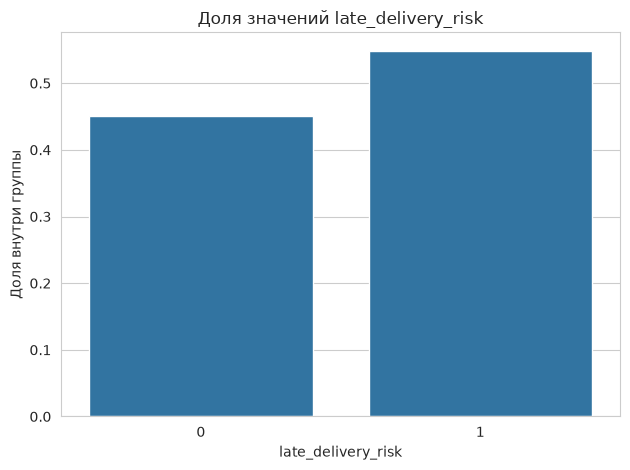

,late_delivery_risk,count_or_share
0,1,0.548814
1,0,0.451186


In [21]:
eda_helper.value_counts(df_orders, TARGET_COL_NAME, normalize=True)

График распределения количества значений целевой переменной подтверждает, что 55% заказов доставляются с опознанием. С точки зрения обучения МЛ-модели мы имеем дело с почти сбалансированными классами.

### Экспресс-анализ остальных признаков

Исследуем таблицу customers и столбцы:
- total_sales
- total_orders
- avg_discount
- return_rate
- recency

,count,mean,std,min,25%,50%,75%,max
total_sales,20647.0,1600.880648,1508.441813,8.47,254.940002,1295.219995,2621.685043,9436.610088


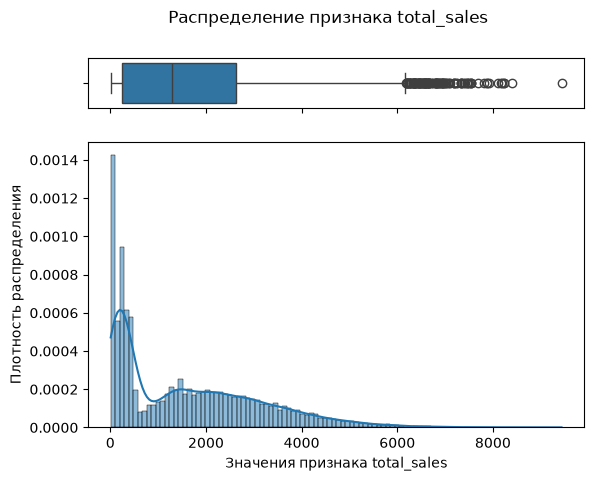

In [22]:
eda_helper.box_hist(df_customers, 'total_sales', bins=100)

Признак имеет длинный правый хвост, но значения выглядят как органические выбросы. Стоит отметить большое клиентов принесших выручку до 500 долларов логистической компании. Вероятно это группа новичков.

,count,mean,std,min,25%,50%,75%,max
total_orders,20647.0,3.184337,2.430756,1.0,1.0,3.0,5.0,15.0


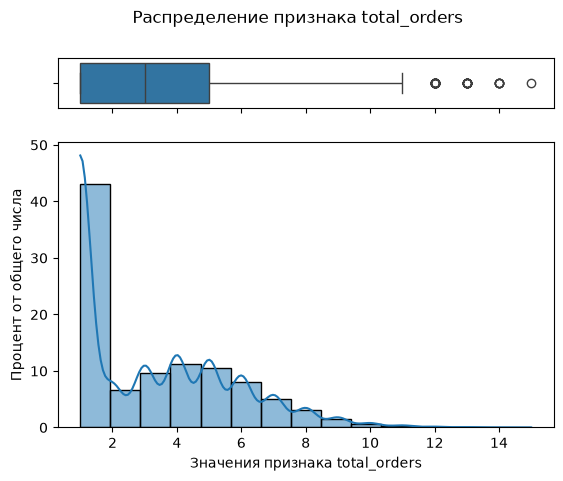

In [23]:
eda_helper.box_hist(df_customers, 'total_orders', bins=15, stat='percent')


Сумма заказов клиентов тоже имеет правых хвост. Выделяется большая группа клиентов (43%) с одним заказом.

,count,mean,std,min,25%,50%,75%,max
avg_discount,20647.0,0.101702,0.048254,0.0,0.07625,0.1,0.123,0.25


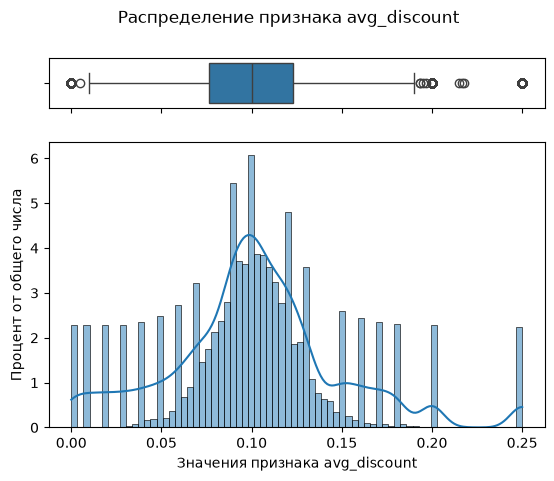

In [24]:
eda_helper = EDAHelper()
eda_helper.box_hist(df_customers, 'avg_discount', stat='percent')


Распределение близкое к колоколообразному, но имеет ряд особенностей - некоторые значения доволно часто встречаются в 2% случаев.
Интересно, что даже в 25 перцентиле средняя скидка ненулевая. То есть почти все пользователи имеют скидки.

,count,mean,std,min,25%,50%,75%,max
return_rate,20647.0,0.042977,0.156624,0.0,0.0,0.0,0.0,1.0


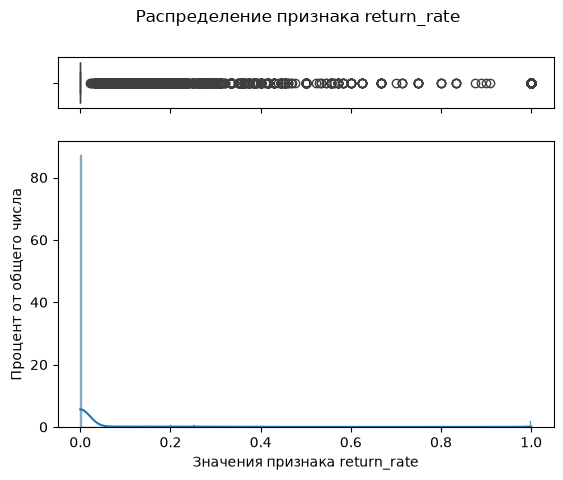

In [25]:
eda_helper.box_hist(df_customers, 'return_rate', stat='percent')


Хорошая новость, что более 85% пользователей не имеют возвратов или "проблемных заказов".

,count,mean,std,min,25%,50%,75%,max
recency,20647.0,221.129026,199.402272,1.0,76.0,160.0,308.0,1126.0


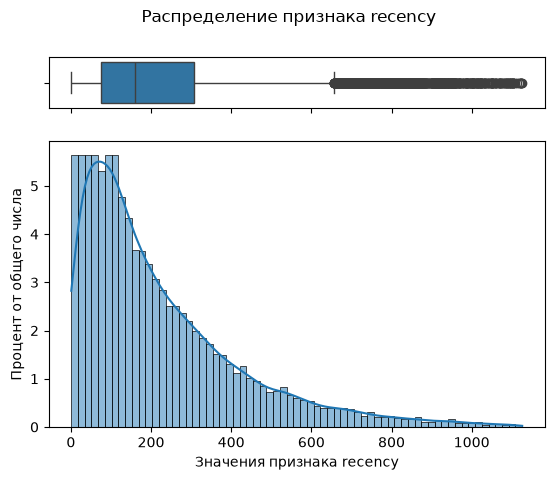

In [26]:
eda_helper.box_hist(df_customers, 'recency', stat='percent')

Recency - сколько дней прошло с момента последнего заказа. В медиане пользователи зака зывают раз в 160 дней. Выбросов, требующих обработки, нет.

Теперь изучим таблицу с заказами:
- shipping_mode
- category_name
- item_price


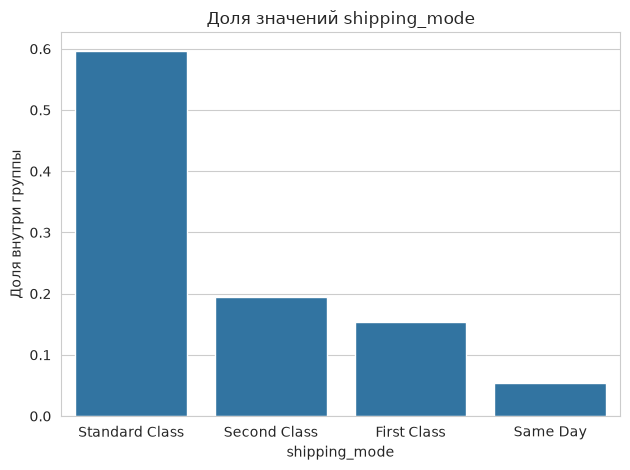

,shipping_mode,count_or_share
0,Standard Class,0.597046
1,Second Class,0.195062
2,First Class,0.154012
3,Same Day,0.053880


In [27]:
eda_helper.value_counts(df_orders, 'shipping_mode', normalize=True)

Больше всего (60%) отправлений следуют Standard Class (видимо самый экономичный). SameDay - только 5%

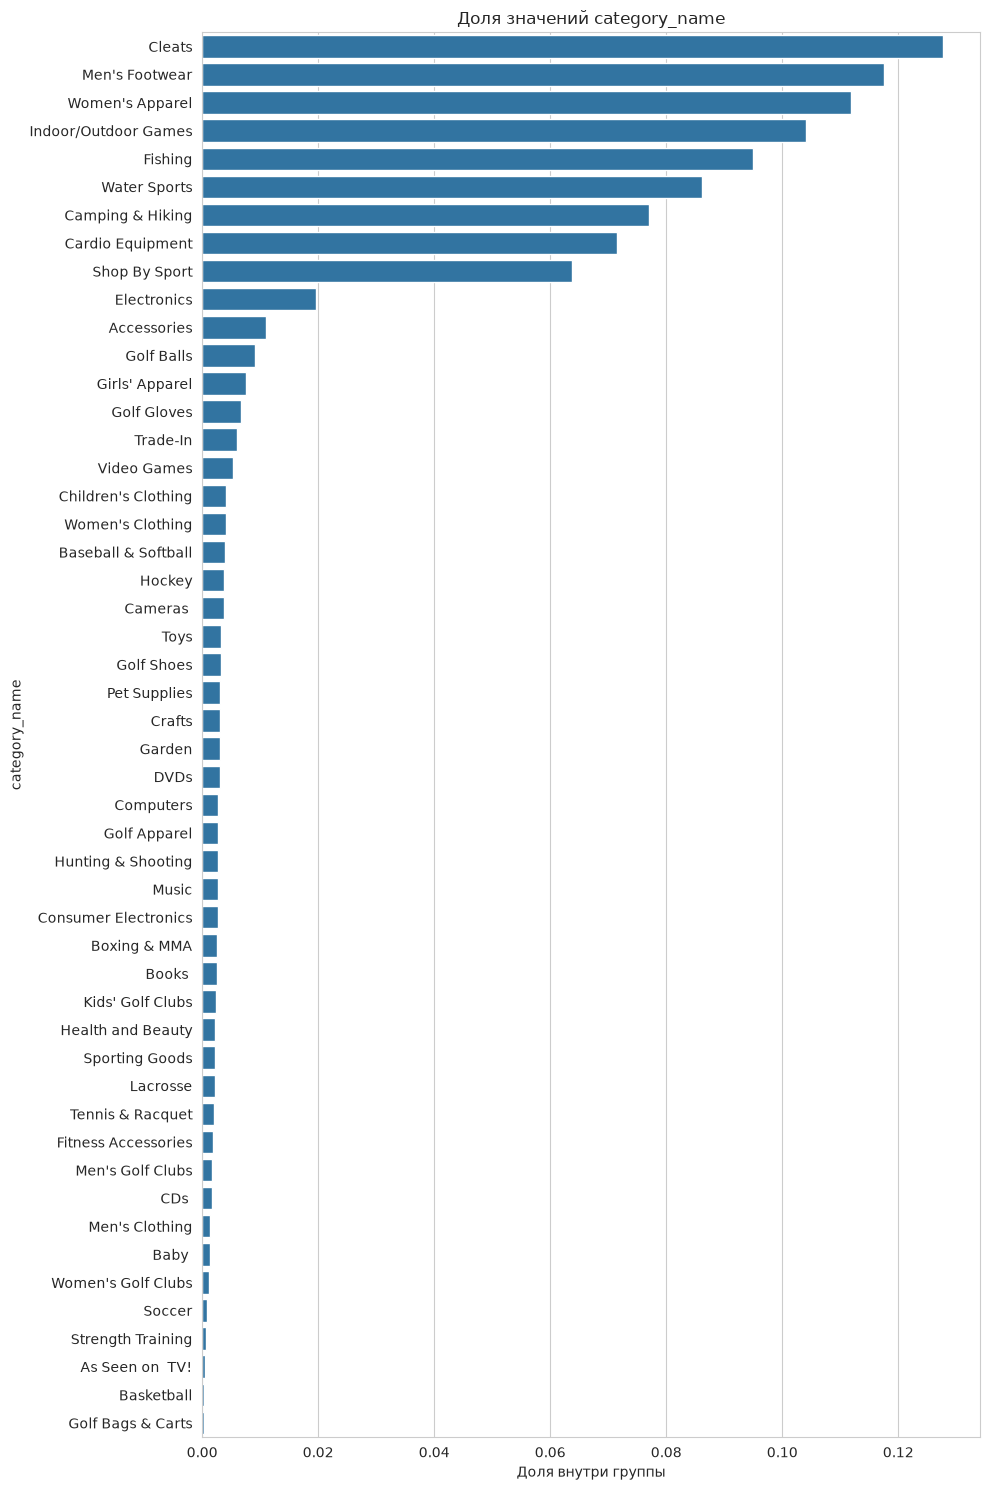

In [28]:
eda_helper = EDAHelper()
eda_helper.value_counts(df_orders, 'category_name', vertical=False, figsize=(10, 15), normalize=True, show_data=False)

В основном производится доставка одежды/обуви, остальные категории очень малочисленны.

,count,mean,std,min,25%,50%,75%,max
item_price,159708.0,142.177623,142.62917,9.99,50.0,70.0,199.990005,1999.98999


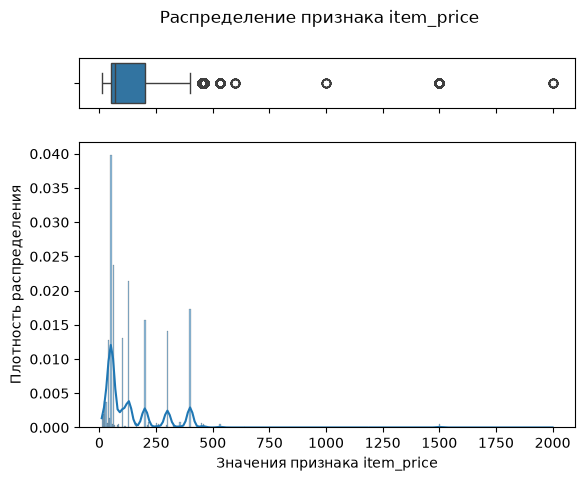

In [29]:
eda_helper.box_hist(df_orders, 'item_price')


Распределение стоимости заказа имеет явные пики в определенных значениях цен. Вероятно это акционные товары или доставка осуществляется согласно сетке цен на разные размеры/типы товаров. В данных имеются выбросы с стоимостью в 1000, 1500 и 2000 долларов. Они не должны значительно повлиять на обучение и кластеризацию, так как отличаются не на порядки.

### Исследование географических аномалий

Исследуем географические данные:

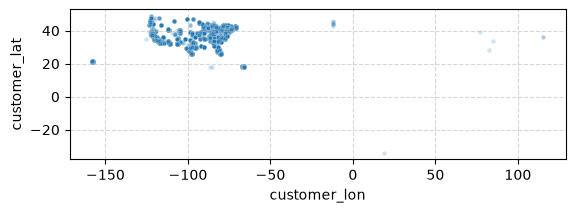

In [30]:
sns.scatterplot(data=df_customers,
                x='customer_lon',
                y='customer_lat',
                s=10,
                alpha=0.2,
                )

plt.gca().set_aspect('equal') # пропрорции карты
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Отобразим эти точки на географической карте:

In [31]:
# Кэширование карт contextily
# Создаем папку 'map_cache' в текущей директории проекта, если её нет
cache_folder = os.path.join(os.getcwd(), 'map_cache')
# Указываем contextily использовать именно её
ctx.set_cache_dir(cache_folder)

def plot_geo_data(
        df, latitude_col='customer_lat', longitude_col='customer_lon',
        hue=None, cluster_centers=None, title='Геоданные'):
    # Инициализируем график нужного размера
    fig, ax = plt.subplots(figsize=(10, 10))

    # 1. Строим оригинальный scatterplot
    sns.scatterplot(
        data=df,
        x=longitude_col,
        y=latitude_col,
        hue=hue,
        palette='viridis' if hue else None,
        s=10,
        alpha=0.7 if hue else 0.2,
        zorder=2,
        ax=ax,
    )

    # 2. Добавляем карту-подложку
    ctx.add_basemap(
        ax=ax,
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        zorder=1,
    )

    # 3. Рисуем центры кластеров
    if cluster_centers is not None:
        ax.scatter(
            x=cluster_centers[:, 1],   # longitude
            y=cluster_centers[:, 0],   # latitude
            marker='x',
            color='red',
            s=200,  # Размер
            linewidths=3,
            zorder=3,  # Поверх всех слоев
        )

    # 4. Настройки отображения
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.5, zorder=1.5)
    ax.set_xlabel('Долгота')
    ax.set_ylabel('Широта')
    ax.set_title(title)
    plt.show()


В значениях координат есть выбросы. Как следует из описания компании CargaPronto - это крупнейший логистический оператор, связывающий производственные хабы Пуэрто-Рико с потребителями в США. Таким образом логистической компании ожидаемо расположены на территории США.
- Поэрто-Рико - остров на востоке от Кубы, фактически являющийся территорией США, где в обращении используются USD и жители имеют гражданство этой страны.
- Сектор на западе от Мексики - Гавайские острова, также принадлежат США. 

Остальные точки расположены на территориях других стран. В связи с большой удаленностью Гавайев от основных кластеров клиентов CargaPronto их следует исключить из рассмотрения, оставив только объекты на территории Северной Америки и Пуэрто-Рико. Это повысит точность прогнозов модели для большинства потребителей.

Удалим геогрефические выбросы:

In [32]:
outside_geo_mask = ~df_customers['customer_lon'].between(-125, -20)
df_customers_to_remove = df_customers[outside_geo_mask]
df_customers_orig = df_customers.copy()
df_customers = df_customers[~outside_geo_mask]

Проверим удаленные объекты:

Удалено 156 объектов из 20647 по географическому признаку


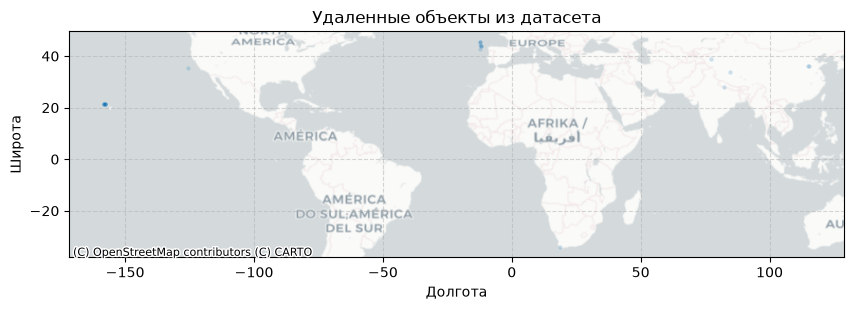

In [33]:
print(f'Удалено {len(df_customers_to_remove)} объектов из {len(df_customers_orig)} по географическому признаку')


plot_geo_data(df_customers_to_remove, title='Удаленные объекты из датасета')

Теперь отобразим оставшиеся объекты, которые будем использовать для обучения модели:

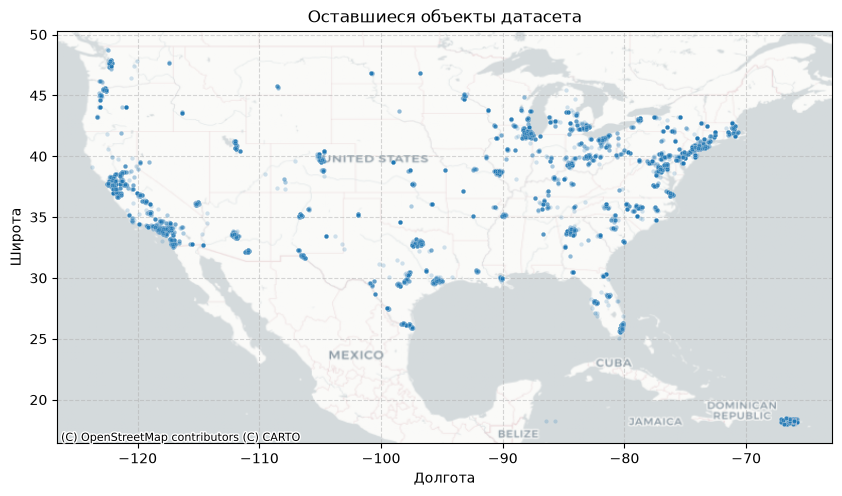

In [34]:
plot_geo_data(df_customers, title='Оставшиеся объекты датасета')

Все они расположены на территории США и Поэрто-Рико. Значит удаление выбросов выполнено корректно.

Теперь удалим "осиротевшие" заказы из таблицы orders:

In [35]:
len_before = len(df_orders)
df_orders = df_orders[~df_orders['customer_id'].isin(df_customers_to_remove['customer_id'])]
diff = len_before - len(df_orders)
diff_pct = diff / len_before * 100
print(f'Удалено {diff} осиротевших заказов из {len_before} ({diff_pct:.1f}%)')

Удалено 1264 осиротевших заказов из 159708 (0.8%)


### Объединение таблиц

In [36]:
df = pd.merge(df_orders, df_customers, on='customer_id', how='left')
print(f'Размер датасета: {df.shape}')
eda_helper.df_info(df)

Размер датасета: (158444, 16)
--------------------------------------------------
Описание датасета :
Датасет  содержит 158444 строк и 16 столбцов.
Размер датасета  в памяти: 18.38 MB
--------------------------------------------------
Данные датасета :
--------------------------------------------------


,place,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,head,180517,20755,0,Standard Class,Sporting Goods,327.750000,1,2,22,18.251453,-66.037056,314.640015,1,0.040000,0.000000,1
1,head,179254,19492,1,Standard Class,Sporting Goods,327.750000,1,5,12,18.279451,-66.037064,311.359985,1,0.050000,0.000000,19
2,head,179253,19491,0,Standard Class,Sporting Goods,327.750000,1,5,12,37.292233,-121.881279,309.720001,1,0.060000,0.000000,19
47615,random,168233,10985,0,Standard Class,Water Sports,199.990005,9,5,13,41.346970,-81.826317,852.340000,1,0.084000,0.000000,145
60790,random,1823,7481,0,Standard Class,Cleats,59.990002,1,6,19,18.259531,-66.370552,3787.360054,6,0.094737,0.000000,384
141770,random,147917,10807,0,Standard Class,Shop By Sport,39.990002,5,4,16,18.232224,-66.370552,4111.770046,7,0.092083,0.166667,265
158441,tail,65129,291,1,Standard Class,Fishing,399.980011,1,4,21,41.629959,-72.967155,5591.820114,5,0.088636,0.000000,202
158442,tail,65126,2813,0,Standard Class,Fishing,399.980011,1,4,20,18.213350,-66.370575,6257.390091,8,0.093846,0.076923,362
158443,tail,65113,7547,0,Standard Class,Fishing,399.980011,1,4,18,18.290380,-66.370613,2844.810036,4,0.111429,0.000000,211


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 158444 entries, 0 to 158443
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            158444 non-null  int64  
 1   customer_id         158444 non-null  int64  
 2   late_delivery_risk  158444 non-null  int64  
 3   shipping_mode       158444 non-null  str    
 4   category_name       158444 non-null  str    
 5   item_price          158444 non-null  float64
 6   order_month         158444 non-null  int32  
 7   order_weekday       158444 non-null  int32  
 8   order_hour          158444 non-null  int32  
 9   customer_lat        158444 non-null  float64
 10  customer_lon        158444 non-null  float64
 11  total_sales         158444 non-null  float64
 12  total_orders        158444 non-null  int64  
 13  avg_discount        158444 non-null  float64
 14  return_rate         158444 non-null  float64

Объединенный датасет имеет 160к строк и 16 столбцов, в том числе 13 значимых признака для обучения.

Так как географический признак (координаты клиента) связан с исследуемой гипотезой, что есть некоторые кластеры, в которых доставка систематически опазнывает, исследуем зависимость целевой переменной от координат:

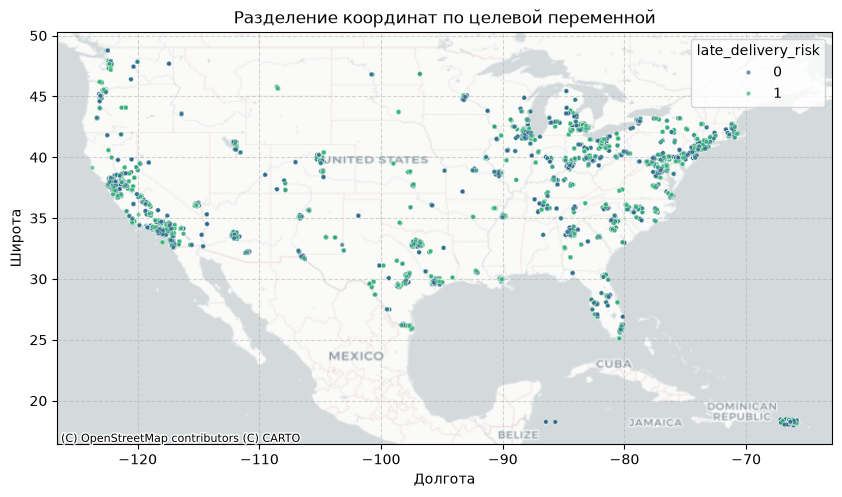

In [37]:
plot_geo_data(df[['customer_lat', 'customer_lon', TARGET_COL_NAME]], hue=TARGET_COL_NAME, title='Разделение координат по целевой переменной')

Есть области с перемешанными классами, но выделяются группы с преимущественно одним классом на карте. 

### Корреляционный анализ

Оценим какие признаки больше имеют наивысшую корреляцию друг с другом и с целевой переменной:

In [38]:
df

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,180517,20755,0,Standard Class,Sporting Goods,327.750000,1,2,22,18.251453,-66.037056,314.640015,1,0.040000,0.000000,1
1,179254,19492,1,Standard Class,Sporting Goods,327.750000,1,5,12,18.279451,-66.037064,311.359985,1,0.050000,0.000000,19
2,179253,19491,0,Standard Class,Sporting Goods,327.750000,1,5,12,37.292233,-121.881279,309.720001,1,0.060000,0.000000,19
3,179252,19490,0,Standard Class,Sporting Goods,327.750000,1,5,11,34.125946,-118.291016,304.809998,1,0.070000,0.000000,19
4,179251,19489,0,Standard Class,Sporting Goods,327.750000,1,5,11,18.253769,-66.037048,298.250000,1,0.090000,0.000000,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158439,65177,1005,0,Standard Class,Fishing,399.980011,1,5,3,40.640930,-73.942711,842.890015,2,0.073333,0.000000,747
158440,65161,9141,1,Second Class,Fishing,399.980011,1,5,1,35.362545,-119.018700,3598.600044,8,0.106190,0.095238,125
158441,65129,291,1,Standard Class,Fishing,399.980011,1,4,21,41.629959,-72.967155,5591.820114,5,0.088636,0.000000,202
158442,65126,2813,0,Standard Class,Fishing,399.980011,1,4,20,18.213350,-66.370575,6257.390091,8,0.093846,0.076923,362


In [39]:
ALL_FEATURES = [
    'shipping_mode',
    'category_name',
    'item_price',
    'order_month',
    'order_weekday',
    'order_hour',
    'customer_lat',
    'customer_lon',
    'total_sales',
    'total_orders',
    'avg_discount',
    'return_rate',
    'recency',
]
phik_matrix = df[ALL_FEATURES + [TARGET_COL_NAME]].phik_matrix(
    interval_cols = ['item_price', 'customer_lat', 'customer_lon', 'total_sales', 'avg_discount', 'return_rate', 'recency']
)

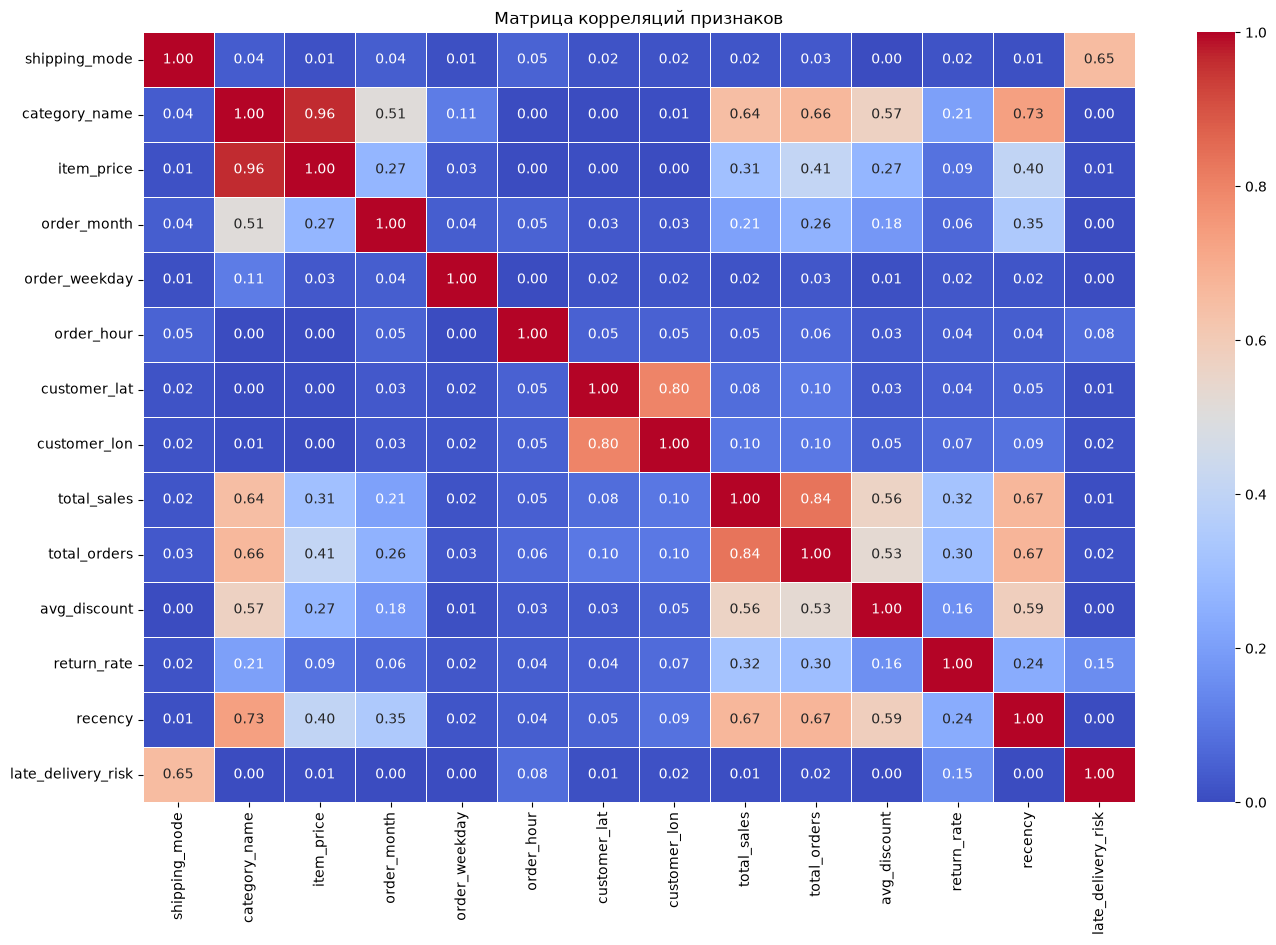

In [40]:

corr_displayer = CorrelationDisplayer(phik_matrix)
corr_displayer.draw_corr_matrix_full()

Координаты сами по себе почти не имеют корреляции с другими признаками.

Есть набор признаков соррелирующих друг с другом. Топ таких признаков удобно посмотреть попарно:

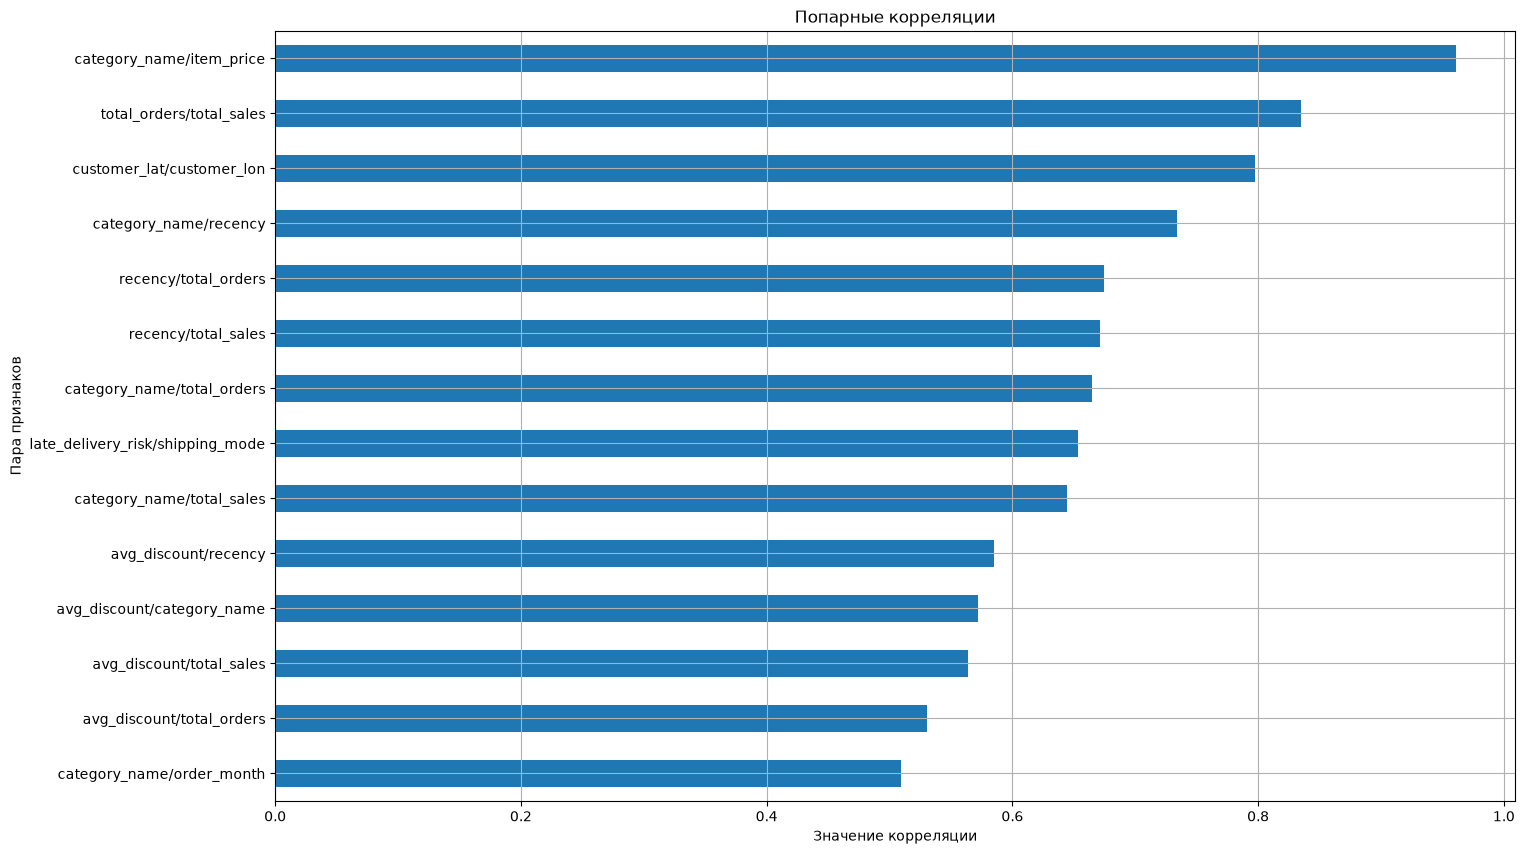

,correlation,order_pair
0,0.961151,category_name/item_price
1,0.835155,total_orders/total_sales
2,0.797099,customer_lat/customer_lon
3,0.733775,category_name/recency
4,0.674358,recency/total_orders
5,0.671575,recency/total_sales
6,0.664958,category_name/total_orders
7,0.653673,late_delivery_risk/shipping_mode
8,0.644588,category_name/total_sales
9,0.585139,avg_discount/recency


In [41]:
corr_displayer.draw_pair_correlations(corr_threshold=0.5)

Значительно коррелируют (почти абсолютно), категория и цена. Логично, некоторые категории связаны с ценой товаров в них.

Также сильно скоррелированы total_orders/total_sales, что так же логично. Попрарных корреляций от средней до сильной набирается 12 пар. Мультиколлинеарность признаков может вызвать проблему для линейной модели, которую мы планируем обучить. В противовес для CatBoost такой проблемы нет.

Посмотрим на корреляцию с целевой переменной:

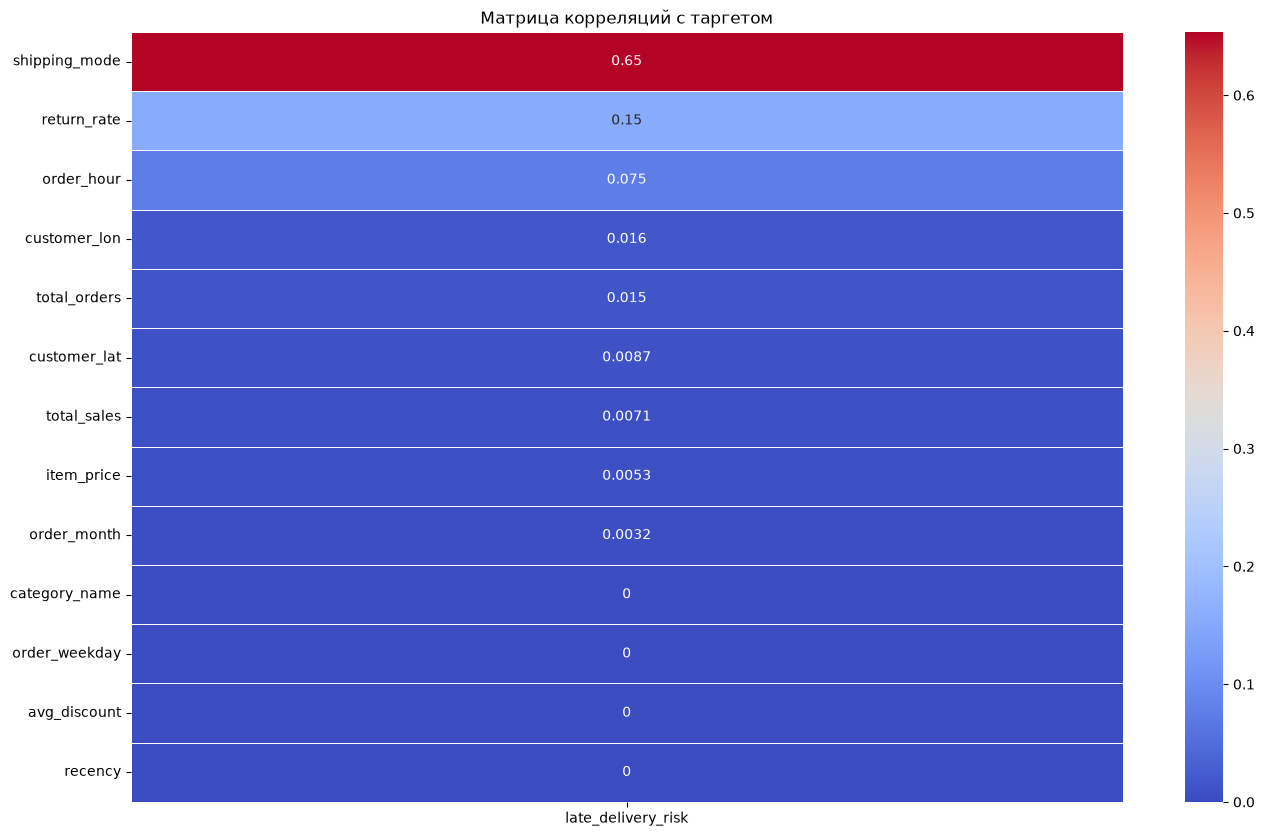

In [42]:
corr_displayer.draw_corr_matrix_with_target(TARGET_COL_NAME)

Значительная корреляция с целевой переменной имеется у признака shipping_mode.

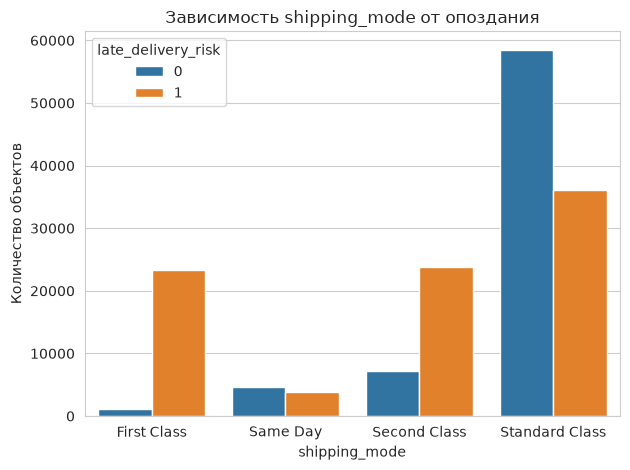

,shipping_mode,late_delivery_risk,count_or_share
0,First Class,0,1140
1,First Class,1,23254
2,Same Day,0,4663
3,Same Day,1,3900
4,Second Class,0,7163
5,Second Class,1,23750
6,Standard Class,0,58516
7,Standard Class,1,36058


In [43]:
eda_helper = EDAHelper()
eda_helper.value_counts(df, 'shipping_mode', hue=TARGET_COL_NAME,
                        title='Зависимость shipping_mode от опоздания')

На графике хорошо прослеживается, что опоздания сильно зависят от класса отправления: First/Second классы имеют превалирующую долю опоздания. Лиш проценты заказов доставляются вовремя этими классами. У Standard Class положение чуть лучше - примерно треть заказов доставляется с опозданием. В Same Date - 50/50.

### Вывод по EDA

**Данные:** Загружены 2 таблицы - customers (20к строк) и orders (180к строк). Пропусков нет ни в одной.

**Дубликаты:** В customers удалено 5 строк-дубликатов по подмножеству признаков без customer_id. В orders - 20к (11.5%) строк с одинаковыми данными включая дату и время заказа вплоть до секунд, что говорит о ошибки при записи данных в источнике. Дополнительно удалено 5 заказов-сирот без профиля клиента.

**Целевая переменная:** Классы почти сбалансированы - 55% задержек и 45% доставок в срок. Специальная обработка дисбаланса не нужна.

**Признаки таблицы customers:**
- **total_sales** - правых хвост, большое клиентов с выручкой до 500$ - вероятно группа новичков
- **total_orders** - правый хвост, 43% клиентов сделали лишь 1 заказ
- **avg_discount** - распределение близкое к нормальному, скидки есть доволно у всех уже с 25-го перцентиля
- **return_rate** - более 85% клиентов без возвратов
- **recency** - медиана 160 дней, выбросов не требующих обработки нет

**Признаки таблицы orders:**
- **shipping_mode** - 60% Standard Class, только 5% Same Day
- **category_name** - в основном одежда и обувь, остальные категории малочисленны
- **item_price** - дискретное распределение с явными пиками цен. Выбросы в 1000–2000$ есть но отличаются не на порядки и не требуют обработки.

**Географический аудит:** Обнаружено 156 клиентов с координатами вне США и Поэрто-Рико (включая Гаваи). В связи с географической удаленностью они исключены. Следом удалены связанные с ними 1264 осиротевших заказа (0.8%). Итоговый объединенный датасет - 158к строк, 16 столбцов (13 значимых признака).

**Корреляционный анализ (phik):** Наибольшая попарная корреляция у пары category_name/item_price - 0.96. Логично: категория товара определяет его ценовой диапазон. Также сильно скоррелированы total_orders/total_sales (0.84) и координаты клиента (0.80). Попрарных корреляций с коэффициентом выше 0.5 набирается 12 пар. Мультиколлинеарность - потенциальная проблема для логистической регрессии, но не для CatBoost.

**Связь с таргетом:** Наиболее значимый предиктор - **shipping_mode** (phik = 0.65). Картина неожиданная: First Class опаздывает в ~95% случаев, Second Class в ~77%. Лиш Standard Class выглядит чуть лучше - задержки у трети заказов. Same Date - 50/50. Эта закономерность предполагает, что быстрые классы доставки системно не справляются со своими обязательствами.

<a id="split"></a>

##  Разделение на выборки

Разделим датасет на выборки, причем будем использовать GroupShuffleSplit, чтобы группировать по customer_id: это делается для исключения перемешивания данных одного пользователя в разных выборках и избегания таким образом утечки данных.

In [44]:
def group_split(df, group_col_name, test_size=0.2, random_state=RANDOM_STATE):
    groups = df[group_col_name]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=groups))
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]
    return (df_train, df_test)
    # для проверки ассертов в check_anti_leakage
    # return train_test_split(df, test_size=test_size, random_state=random_state)

# для объединенного датасета
df_train, df_val_test = group_split(df, 'customer_id', test_size=0.4)
df_val, df_test = group_split(df_val_test, 'customer_id', test_size=0.5)

# для таблицы с заказами (для базовых моделей)
df_train_orders, df_val_test_orders = group_split(df_orders, 'customer_id', test_size=0.4)
df_val_orders, df_test_orders = group_split(df_val_test_orders, 'customer_id', test_size=0.5)


In [45]:
# Проверим, что заказы одного пользователя не протекают в разные выборки
def check_anti_leakage(df_train, df_val, df_test, group_col_name):
    assert len(df_train) + len(df_val) + len(df_test) == len(df)
    assert len(set(df_train[group_col_name]) & set(df_val[group_col_name])) == 0
    assert len(set(df_train[group_col_name]) & set(df_test[group_col_name])) == 0
    assert len(set(df_val[group_col_name]) & set(df_test[group_col_name])) == 0

check_anti_leakage(df_train, df_val, df_test, 'customer_id')
check_anti_leakage(df_train_orders, df_val_orders, df_test_orders, 'customer_id')

<a id="baseline"></a>

## Обучение базовой модели

Опреледим, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

Объявляем фичи в группы - категориальные и числовые. Причем категориальные признаки будем кодировать по-разному - в зависимости от кардинальности. Признак category_name имеет более 20 значений, его будем кодировать с помощью TargetEncoder.

In [46]:
ohe_features = [
    'shipping_mode',
]
te_features = [
    'category_name'
]
cat_features = ohe_features + te_features
num_features = [
    'item_price',
    'order_hour',
    'order_weekday',
    'order_month',
]
cols_to_drop = [
    'customer_id',
    'order_id',
    TARGET_COL_NAME
]
features = cat_features + num_features


Определим предобработку признаков внутри Pipeline. Числовые признаки масштабируем с помощью StandardScaler, а категориальные признаки кодируем с помощью соответствующих энкодеров.

In [47]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_te_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', TargetEncoder()),
])

cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(sparse_output=False, drop='first')), # drop для избегания dummy ловушки в LogReg
])

def get_preprocessor(num_features, te_features, ohe_features):
    return ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('te', cat_te_pipeline, te_features),
        ('ohe', cat_ohe_pipeline, ohe_features),
    ], remainder='drop')

Определим модели, которые будем обучать, встроив их в Pipeline:

In [48]:
def pipe(model, preprocessor=None):
    steps = []
    if preprocessor:
        steps.append(('preprocessor', preprocessor))
    steps.append(('model', model))
    return Pipeline(steps)


DEFAULT_MODEL_PARAMS = {
    'random_state': RANDOM_STATE,
}
DEFAULT_CBM_MODEL_PARAMS = {
    'eval_metric': 'AUC',
    'early_stopping_rounds': 100,
    **DEFAULT_MODEL_PARAMS,
}
DEFAULT_LOGREG_PARAMS = {
    'max_iter': 2000,
    'solver': 'lbfgs',
    **DEFAULT_MODEL_PARAMS,
}
pipelines = {
    'catboost': {
        'model': pipe(CatBoostClassifier(**DEFAULT_CBM_MODEL_PARAMS)),
        'fit_params' : {
            'model__cat_features': cat_features,
            'model__verbose': False
        },
    },
    'logreg': {
        'model': pipe(
            LogisticRegression(**DEFAULT_LOGREG_PARAMS),
            preprocessor=get_preprocessor(num_features, te_features, cat_features)
        ),
    },
}

Обучим модели в пайплайнах:

In [49]:
X_train = df_train_orders.drop(columns=cols_to_drop)
y_train = df_train_orders[TARGET_COL_NAME]
X_val = df_val_orders.drop(columns=cols_to_drop)
y_val = df_val_orders[TARGET_COL_NAME]

def calc_all_metrics(model_name, y_sample, y_pred, y_pred_proba, fit_time=None):
    mtrcs = {
        'model': f'{model_name}',
        'ROC-AUC': roc_auc_score(y_sample, y_pred_proba[:, 1]),
        'Accuracy': accuracy_score(y_sample, y_pred),
        'Precision': precision_score(y_sample, y_pred),
        'Recall': recall_score(y_sample, y_pred),
        'F1': f1_score(y_sample, y_pred),
    }
    if fit_time is not None:
        mtrcs['fit_time'] = fit_time
    return mtrcs

baseline_metrics = []
for model_name, model_conf in pipelines.items():
    print(f'Обучение модели {model_name}')
    pipeline = model_conf['model']
    fit_params = model_conf.get('fit_params', {})
    if model_name == 'catboost':
        fit_params.update({'model__eval_set': [(X_val, y_val)]})
    wall_time = WallTime()
    pipeline.fit(X_train, y_train, **fit_params)
    elapsed_seconds = wall_time.elapsed_seconds()
    print(f'Модель {model_name} обучена за {elapsed_seconds} секунд')

    y_pred = pipeline.predict(X_val)
    y_pred_proba = pipeline.predict_proba(X_val)
    y_pred_train = pipeline.predict(X_train)
    y_pred_proba_train = pipeline.predict_proba(X_train)
    metrics = calc_all_metrics(model_name, y_val, y_pred, y_pred_proba)
    metrics_train = calc_all_metrics(f'{model_name}_train', y_train, y_pred_train, y_pred_proba_train)
    baseline_metrics.append(metrics)
    baseline_metrics.append(metrics_train)

pd.DataFrame(baseline_metrics).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)


Обучение модели catboost
Модель catboost обучена за 2.9216549396514893 секунд
Обучение модели logreg


/Users/ngsmirnov/nikki/projects/practicum/sprint18_catboost_clasterization_bin_classif/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Модель logreg обучена за 0.43985795974731445 секунд


,model,ROC-AUC,Accuracy,Precision,Recall,F1
0,catboost_train,0.766646,0.718530,0.858857,0.583705,0.695040
1,catboost,0.764420,0.722201,0.855848,0.593157,0.700691
2,logreg,0.731947,0.704721,0.850686,0.559583,0.675090
3,logreg_train,0.730966,0.699200,0.852639,0.547168,0.666573


Базовые модели показывают следующие результаты по целевой метрике ROC-AUC:
- catboost: 0.764
- logreg: 0.732

Результаты базовых моделей достаточно близки, но лучше catboost. Обе модели не переобучились, что следует из сравнения метрик на трейне и на валидации - на обеих выборках метрики показывают очень близкие значения и отличаются только в тысячных.

Катбуст близок по целевой метрике к бизнес-требованию roc-auc>0.75. Кластеризация объектов по местоположению и профилям клиентов с выделением новых признаков должна помочь достичь требуемого качества.

<a id="geo_cluster"></a>

##  Кластеризация по признакам, связанным с местоположением



Подготовим датасет для кластеризации по географическому признаку. Для этого выполним следующие шаги:

- Предобработка признаков - кодирование категориальных переменных и масштабирование числовых.
    - Все преобразования реализованы внутри пайплайна и применяются только на тренировочной выборке, чтобы исключить утечку данных. 
    - Формально в машстабировании нет необходимости, так как единицы измерения - координаты. Но если взглнуть на карту объектов в выборке, то видно что диапазон значений долготы больше, чем диапазон широт. Да, в данном случае диапазоны отличаются не на порядке, но в общем случае могут отличаться значительно, поэтому маштабирование целевообрабно.

- Подбор гиперпараметра n_clusters - методом локтя: перебираем значения n_clusters и для каждого вычисляем внутрикластерную сумму квадратов расстояний (WCSS). Оптимальное число кластеров определяется по точке перегиба на графике.

Воспользуемся helper-классом для кластеризации данных:

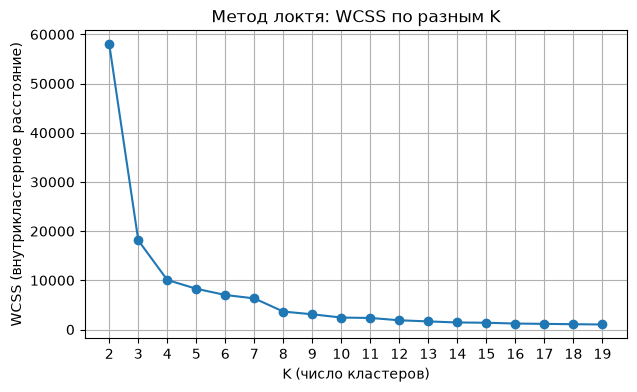

In [50]:
class ClusteringHelper:
    def __init__(self, df_train, clustering_columns, preprocessor=None, random_state=RANDOM_STATE):
        self.df_train_ = df_train
        self.clustering_columns_ = clustering_columns
        self.preprocessor_ = preprocessor
        self.rs_ = random_state

    def make_kmeans_(self, n_clusters):
        return KMeans(n_clusters=n_clusters, random_state=self.rs_, init='k-means++')

    def make_kmeans_pipeline_(self, n_clusters):
        steps = []
        if self.preprocessor_ is not None:
            steps.append(('preprocessor', self.preprocessor_))
        steps.append(('kmeans', self.make_kmeans_(n_clusters)))
        return Pipeline(steps)

    def plot_elbow_method(self, cluster_range=range(2, 20)):
        wcss = []
        ks = cluster_range

        X_train_coord = self.df_train_[self.clustering_columns_]

        for n_clusters in ks:
            km_pipeline = self.make_kmeans_pipeline_(n_clusters)
            km_pipeline.fit(X_train_coord)
            inertia = km_pipeline.named_steps['kmeans'].inertia_  # Получаем WCSS из обученного пайплайна
            wcss.append(inertia)

        # Визуализация графика по методу локтя
        plt.figure(figsize=(7, 4))
        plt.plot(list(ks), wcss, marker='o') # x - количество кластеров, y - WCSS
        plt.xticks(list(ks))
        plt.xlabel('K (число кластеров)')
        plt.ylabel('WCSS (внутрикластерное расстояние)')
        plt.title('Метод локтя: WCSS по разным K')
        plt.grid(True)
        plt.show()

    def fit_make_features(self, n_clusters, df_val=None, df_test=None, features_suffix=''):
        # обучаем kmeans только на трейн выборке
        km_pipeline = self.make_kmeans_pipeline_(n_clusters)
        X_train_coord = self.df_train_[self.clustering_columns_]
        X_val_coord = df_val[self.clustering_columns_] if df_val is not None else None
        X_test_coord = df_test[self.clustering_columns_] if df_test is not None else None

        km_pipeline.fit(X_train_coord)
        kmeans_prep = km_pipeline.named_steps['preprocessor']
        kmeans_model = km_pipeline.named_steps['kmeans']

        # препроцессим координаты во всех выборках
        X_train_coord_preprocessed = kmeans_prep.transform(X_train_coord)
        X_val_coord_preprocessed = kmeans_prep.transform(X_val_coord) if df_val is not None else None
        X_test_coord_preprocessed = kmeans_prep.transform(X_test_coord) if df_test is not None else None

        # получаем метки кластеров для всех объектов в каждой выборке (новый признак в датасете)
        # используем preprocessed данные: kmeans обучен на масштабированных координатах!
        train_clusters = kmeans_model.predict(X_train_coord_preprocessed)
        val_clusters = kmeans_model.predict(X_val_coord_preprocessed) if df_val is not None else None
        test_clusters = kmeans_model.predict(X_test_coord_preprocessed) if df_test is not None else None

        # центроиды в scaled-пространстве для расчёта расстояний
        train_centers_scaled = kmeans_model.cluster_centers_[train_clusters]
        val_centers_scaled = kmeans_model.cluster_centers_[val_clusters] if df_val is not None else None
        test_centers_scaled = kmeans_model.cluster_centers_[test_clusters] if df_test is not None else None

        self.cluster_centers_ = kmeans_model.cluster_centers_

        # считаем расстояние от объекта до своего центройда (еще один признак в датасете)
        def distance(a, b):
            return np.sqrt(np.sum((a - b)**2, axis=1))

        train_dist_to_own = distance(X_train_coord_preprocessed, train_centers_scaled)
        val_dist_to_own = distance(X_val_coord_preprocessed, val_centers_scaled) if df_val is not None else None
        test_dist_to_own = distance(X_test_coord_preprocessed, test_centers_scaled) if df_test is not None else None

        # собираем датафрейм с новыми признаками
        train_meta_df = pd.DataFrame(
            {f'{features_suffix}cluster_id': train_clusters, f'{features_suffix}dist_to_own_center': train_dist_to_own},
            index=self.df_train_.index
        )
        val_meta_df = pd.DataFrame(
            {f'{features_suffix}cluster_id': val_clusters, f'{features_suffix}dist_to_own_center': val_dist_to_own},
            index=df_val.index
        ) if df_val is not None else None
        test_meta_df = pd.DataFrame(
            {f'{features_suffix}cluster_id': test_clusters, f'{features_suffix}dist_to_own_center': test_dist_to_own},
            index=df_test.index
        ) if df_test is not None else None

        # объединяем датафреймы с новыми признаками
        self.df_train_ = pd.concat([self.df_train_, train_meta_df], axis=1)
        df_val = pd.concat([df_val, val_meta_df], axis=1)
        df_test = pd.concat([df_test, test_meta_df], axis=1)

        return (self.df_train_, df_val, df_test)

    def get_cluster_centers(self):
        if self.cluster_centers_ is None:
            raise RuntimeError('No cluster centers found: call fit method before')
        return self.cluster_centers_

GEO_FEATURES = ['customer_lat', 'customer_lon']
geo_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), GEO_FEATURES),
])
geo_clustering_helper = ClusteringHelper(df_train, GEO_FEATURES, geo_preprocessor)
geo_clustering_helper.plot_elbow_method()

Оптимальным количеством кластеров является 4 - после него внутри-кластерное расстояние WCSS уменьшаяется незначительно.

Обучим KMeans на оптимальном количестве кластеров:

In [51]:
optimal_n_clusters = 4

df_train, df_val, df_test = geo_clustering_helper.fit_make_features(optimal_n_clusters, df_val, df_test, features_suffix='geo_')

# обратное преобразование центроидов в реальные координаты lat/lon для визуализации
num_transformer = geo_preprocessor.named_transformers_['num']
cluster_centers_geo = num_transformer.inverse_transform(geo_clustering_helper.get_cluster_centers())

Проверим присоединенные новые признаки:

In [52]:
df_train.sample(10, random_state=RANDOM_STATE)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency,geo_cluster_id,geo_dist_to_own_center
67009,97647,5353,1,Second Class,Water Sports,199.990005,7,0,0,35.187542,-101.867622,3024.839996,5,0.098000,0.000000,474,1,0.752885
147680,53453,9502,1,Standard Class,Accessories,24.990000,11,6,23,31.894634,-106.412071,5614.490044,8,0.109375,0.156250,178,1,0.657344
132401,48676,2958,1,First Class,Accessories,24.990000,10,0,6,18.211214,-66.370529,3480.680048,7,0.095714,0.000000,224,0,0.004394
39207,118206,6853,1,First Class,Shop By Sport,39.990002,11,0,4,39.888641,-84.076012,2658.480015,5,0.076154,0.000000,270,2,0.204297
89624,84454,4514,0,Standard Class,Indoor/Outdoor Games,49.980000,5,6,20,34.070080,-117.937195,5204.300045,8,0.123103,0.172414,298,1,0.179376
146429,116694,6932,0,Standard Class,Camping & Hiking,299.980011,11,5,8,40.645714,-73.897217,3948.420050,8,0.107273,0.181818,350,2,0.312655
150733,132858,1889,0,Standard Class,Shop By Sport,39.990002,2,2,4,33.891930,-84.481270,3964.530075,6,0.108750,0.208333,351,3,0.467727
50918,64207,3209,0,Standard Class,Girls' Apparel,39.990002,1,6,3,18.280163,-66.370560,1094.780025,4,0.048333,0.000000,510,0,0.003309
18321,139387,2595,0,Standard Class,Cleats,59.990002,3,4,12,18.202715,-66.370567,6157.430100,8,0.101111,0.000000,123,0,0.005219
443,123770,9597,0,Second Class,Cardio Equipment,99.989998,12,4,21,18.241154,-66.370567,5363.330074,9,0.116071,0.035714,259,0,0.001858


Добавлены новые признаки:
- geo_cluster_id
- geo_dist_to_own_center

Построим график с полученными кластерами и нанесем на него центроиды кластеров.

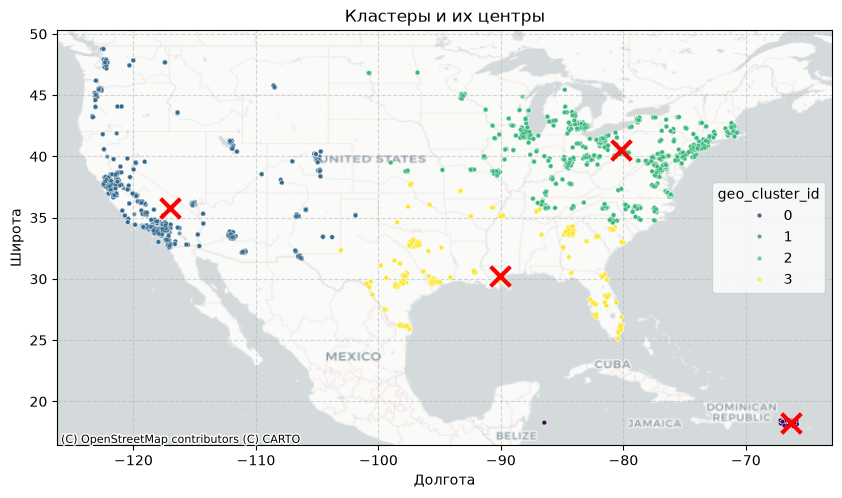

In [53]:
plot_geo_data(df_train, hue='geo_cluster_id', cluster_centers=cluster_centers_geo, title='Кластеры и их центры')

На карте хорошо видно, что клиенты разбиты по координатам на 4 кластера: запад, восток, юго-восток и Пуэрто-Рико.

<a id="beh_cluster"></a>

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



Подготовим признаки RFM (Retency, Frequency (total_orders), Monetary (total_sales)) и другие для кластеризации клиентов.

In [54]:

RFM_FEATURES = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']

# Препроцессор для RFM-кластеризации включает в себя только масштабирование, так как категориальных фичей среди признаков нет.

rfm_kmeans_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), RFM_FEATURES),
])


Найдем оптимальный n_clusters методом локтя:

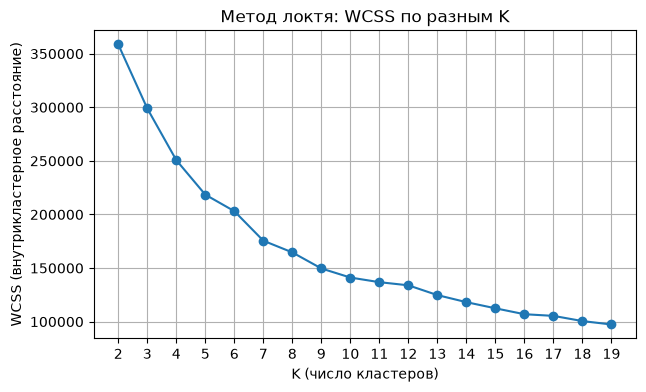

In [55]:
rfm_clustering_helper = ClusteringHelper(df_train, RFM_FEATURES, rfm_kmeans_preprocessor)
rfm_clustering_helper.plot_elbow_method()

Оптимальным выглядит значение 7.

Обучим кластеризатор на подобранном по графику n_clusters и сформируем новые признаки на основе кластров:

In [56]:
optimal_n_clusters = 7
df_train, df_val, df_test = rfm_clustering_helper.fit_make_features(optimal_n_clusters, df_val, df_test, features_suffix='rfm_')
df_train.sample(10, random_state=RANDOM_STATE)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency,geo_cluster_id,geo_dist_to_own_center,rfm_cluster_id,rfm_dist_to_own_center
67009,97647,5353,1,Second Class,Water Sports,199.990005,7,0,0,35.187542,-101.867622,3024.839996,5,0.098000,0.000000,474,1,0.752885,2,1.024186
147680,53453,9502,1,Standard Class,Accessories,24.990000,11,6,23,31.894634,-106.412071,5614.490044,8,0.109375,0.156250,178,1,0.657344,6,1.369012
132401,48676,2958,1,First Class,Accessories,24.990000,10,0,6,18.211214,-66.370529,3480.680048,7,0.095714,0.000000,224,0,0.004394,0,0.857134
39207,118206,6853,1,First Class,Shop By Sport,39.990002,11,0,4,39.888641,-84.076012,2658.480015,5,0.076154,0.000000,270,2,0.204297,0,1.114595
89624,84454,4514,0,Standard Class,Indoor/Outdoor Games,49.980000,5,6,20,34.070080,-117.937195,5204.300045,8,0.123103,0.172414,298,1,0.179376,6,1.705609
146429,116694,6932,0,Standard Class,Camping & Hiking,299.980011,11,5,8,40.645714,-73.897217,3948.420050,8,0.107273,0.181818,350,2,0.312655,1,1.330228
150733,132858,1889,0,Standard Class,Shop By Sport,39.990002,2,2,4,33.891930,-84.481270,3964.530075,6,0.108750,0.208333,351,3,0.467727,1,0.845435
50918,64207,3209,0,Standard Class,Girls' Apparel,39.990002,1,6,3,18.280163,-66.370560,1094.780025,4,0.048333,0.000000,510,0,0.003309,4,2.193762
18321,139387,2595,0,Standard Class,Cleats,59.990002,3,4,12,18.202715,-66.370567,6157.430100,8,0.101111,0.000000,123,0,0.005219,6,1.070235
443,123770,9597,0,Second Class,Cardio Equipment,99.989998,12,4,21,18.241154,-66.370567,5363.330074,9,0.116071,0.035714,259,0,0.001858,6,0.744544


Проанализируем полученные кластеры:

In [57]:
# 'recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']
df_train.groupby(['rfm_cluster_id']).agg(
    delivery_late_rate=('late_delivery_risk', 'mean'),
    orders_count=('order_id', 'count'),
    customer_count=('customer_id', 'nunique'),
    item_price_avg=('item_price', 'mean'),
    recency_avg=('recency', 'mean'),
    total_orders_avg=('total_orders', 'mean'),
    total_sales_avg=('total_sales', 'mean'),
    return_rate_avg=('return_rate', 'mean'),
    avg_discount_avg=('avg_discount', 'mean'),
)

,delivery_late_rate,orders_count,customer_count,item_price_avg,recency_avg,total_orders_avg,total_sales_avg,return_rate_avg,avg_discount_avg
rfm_cluster_id,,,,,,,,,
0,0.569451,34319,2530,133.609419,238.235351,5.330866,2894.742150,0.004199,0.102979
1,0.448966,10395,726,133.334530,261.105532,5.689562,3152.750740,0.233694,0.103179
2,0.560147,13334,1588,131.332179,581.459727,3.841608,2112.306050,0.009800,0.100277
3,0.576282,6181,2743,186.569872,194.752953,2.457369,1092.871324,0.003047,0.149100
4,0.565706,8462,3442,183.044044,186.171827,2.517844,1228.262387,0.003489,0.066728
5,0.234637,1253,352,154.381336,374.679968,2.849162,1439.221665,0.605119,0.100775
6,0.564218,21139,913,136.875524,227.791334,8.554047,4985.555918,0.028890,0.100004


Охарактеризуем пользователей в найденных кластерах:

**Кластер 0 - Активные стабильные (2530 клиентов)**
- total_orders_avg=5.33 - средняя частота заказов
- total_sales_avg=2895 - средняя выручка
- recency_avg=238 - заказывали относительно недавно
- return_rate=0.004 - практически не возвращают товары
- delivery_late_rate=0.57 - типичный уровень задержек, мирятся с ним

**Кластер 1 - Разочарованные (726 клиентов)**
- return_rate=0.234 - очень высокий, каждый 4-й заказ проблемный
- recency_avg=261 - давно не заказывали
- total_sales_avg=3153 - средняя выручка
- delivery_late_rate=0.45 - самый низкий среди всех кластеров
- Вероятно, уходят не из-за задержек, а из-за качества товаров/сервиса - возвраты говорят о недовольстве

**Кластер 2 - Спящие (1588 клиентов)**
- recency_avg=581 - не заказывали почти 1.5 года
- total_orders_avg=3.84 - мало заказов за всё время
- total_sales_avg=2112 - низкая выручка
- return_rate=0.010 - довольны качеством, просто неактивны
- Кандидаты на реактивационные кампании

**Кластер 3 - Новые дорогие покупатели (2743 клиента)**
- recency_avg=195 - относительно новые клиенты
- total_orders_avg=2.46 - очень мало заказов (новые)
- item_price_avg=186.6 - самый высокий средний чек
- avg_discount_avg=0.149 - самая высокая скидка (возможно, пришли по промо)
- return_rate=0.003 - минимальные проблемы
- Потенциал роста при правильной работе с лояльностью

**Кластер 4 - Новые экономные покупатели (3442 клиента)**
- recency_avg=186 - самые свежие клиенты
- total_orders_avg=2.52 - очень мало заказов
- item_price_avg=183 - высокий средний чек
- avg_discount_avg=0.067 - самая низкая скидка (платят полную цену)
- return_rate=0.003 - минимальные проблемы
- Самая большая группа новичков, покупают без скидок

**Кластер 5 - Критические возвращатели (352 клиента)**
- return_rate=0.605 - более половины заказов возвращается!
- delivery_late_rate=0.235 - самый низкий из всех: не терпят задержек и возвращают товар
- recency_avg=375 - давно неактивны
- Требуют отдельного анализа - возможно, проблема в конкретных категориях товаров

**Кластер 6 - VIP-лояльные (913 клиентов)**
- total_orders_avg=8.55 - заказывают чаще всех!
- total_sales_avg=4986 - приносят наибольшую выручку!
- recency_avg=228 - относительно недавно
- return_rate=0.029 - почти не возвращают товары
- delivery_late_rate=0.564 - страдают от задержек, но остаются лояльными
- Ключевой сегмент для удержания

Визуализируем положение кластеров с помощью t-SNE:

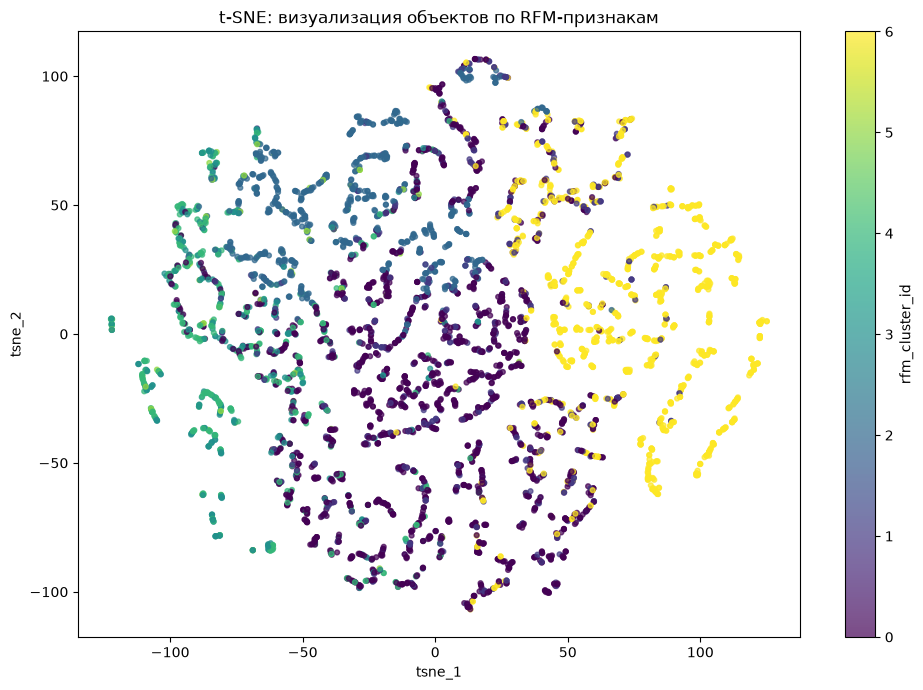

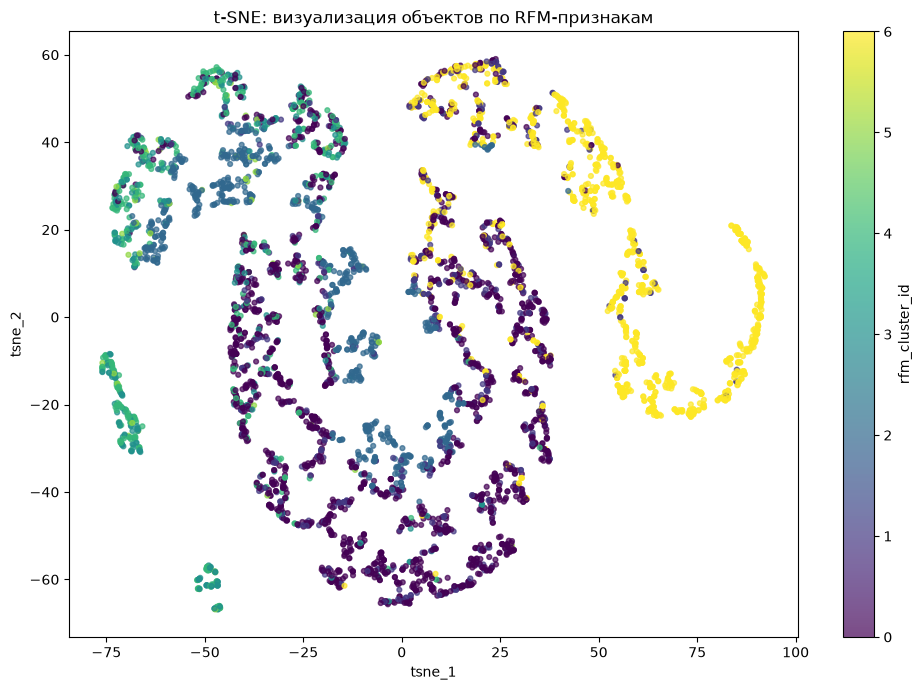

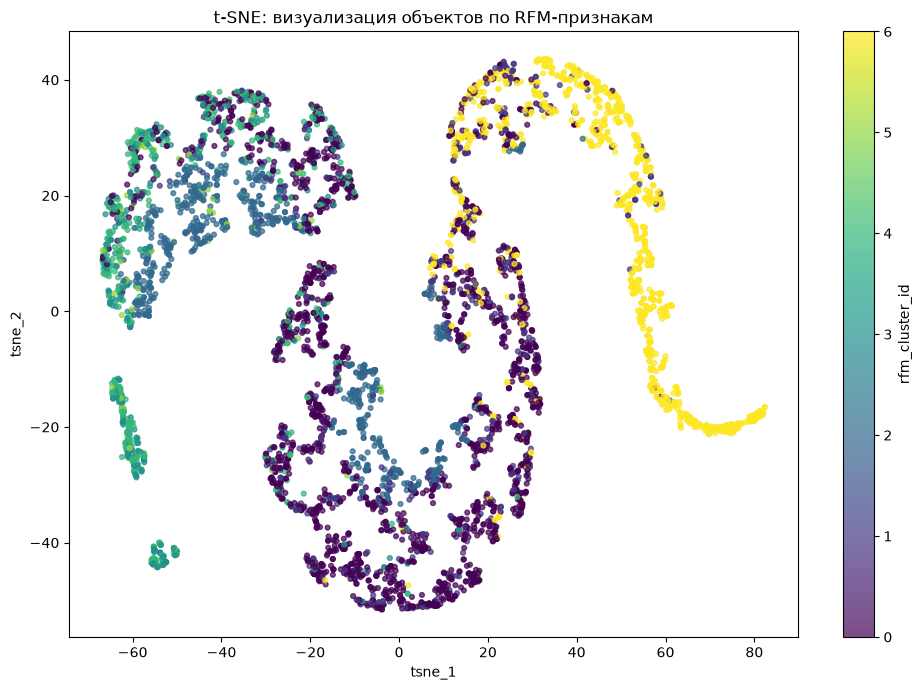

In [58]:
def plot_tsne(df, features = [], preprocessor=None, perplexity=50, hue=None):
    # 1. Создаём модель t-SNE и фиксируем ключевые параметры проекции
    tsne = TSNE(
        n_components=2, # выбираем 2D-координаты
        perplexity=perplexity, # масштаб локального окружения
        init='pca', # стартовая инициализация через PCA
        random_state=RANDOM_STATE,
        learning_rate='auto'
    )
    # 2. Запускаем оптимизацию и получаем матрицу координат (n_samples, 2)
    df_train_sample = df.sample(5000, random_state=RANDOM_STATE)
    df_rfm = df_train_sample[features]
    df_train_rfm_scaled = df_rfm if preprocessor is None else preprocessor.transform(df_rfm)
    X_tsne = tsne.fit_transform(df_train_rfm_scaled)

    # 3. Упаковываем координаты в таблицу для дальнейшей визуализации
    tsne_df = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])

    # 4. Отдельно сохраняем признак для раскраски и добавляем в таблицу
    color_col_name = hue
    color_values = df_train_sample[color_col_name].values
    tsne_df[color_col_name] = color_values

    # 5. Строим диаграмму рассеяния
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        tsne_df['tsne_1'],
        tsne_df['tsne_2'],
        c=tsne_df[color_col_name],
        s=12,
        alpha=0.7,
    )

    plt.title('t-SNE: визуализация объектов по RFM-признакам')
    plt.xlabel('tsne_1')
    plt.ylabel('tsne_2')
    plt.colorbar(scatter, label=color_col_name)

    plt.tight_layout()
    plt.show()

for perp in [10, 30, 50]:
    plot_tsne(df_train, perplexity=perp, features=RFM_FEATURES, hue='rfm_cluster_id')

С разным гиперпараметром perplexity картина неустойчива. При малом perplexity (10) учитываются меньше соседей и глобальная структура не видна. При повышении до 30 и 50 видна глобальная структура:
-  7 и 1 кластеры бизки друг другу и меют "мостик".
- Выделяется кластер 5 (зелено-голубые точки)
- остальные кластеры значительно смешаны с соседними

В итоге можно сказать, что кластеры действительно отличаются друг от друга и должны давать полезный сигнал для модели.

Попробуем раскрасить объекты по целевой переменной:

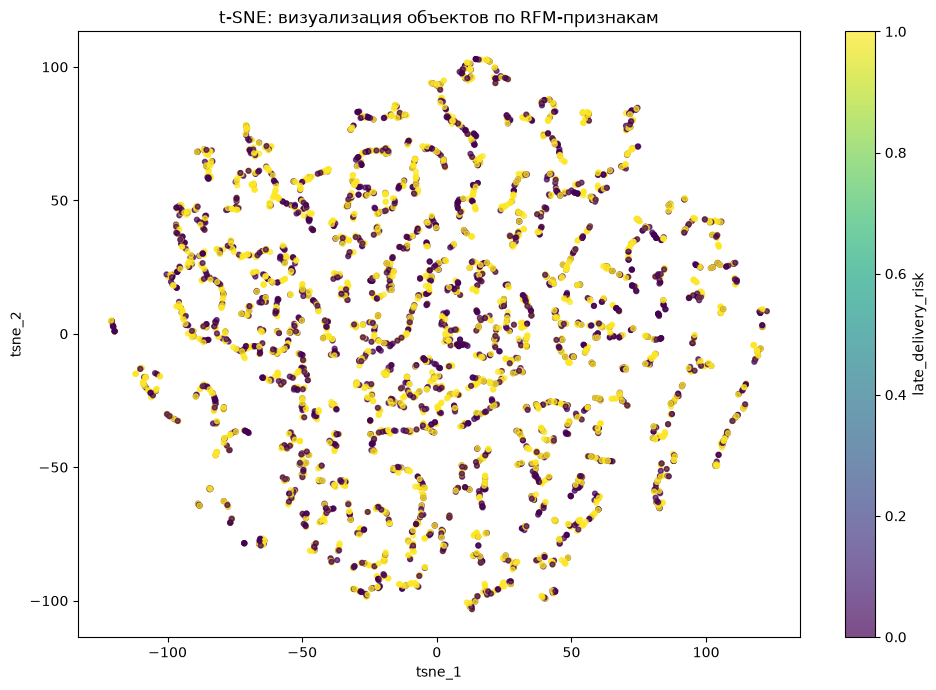

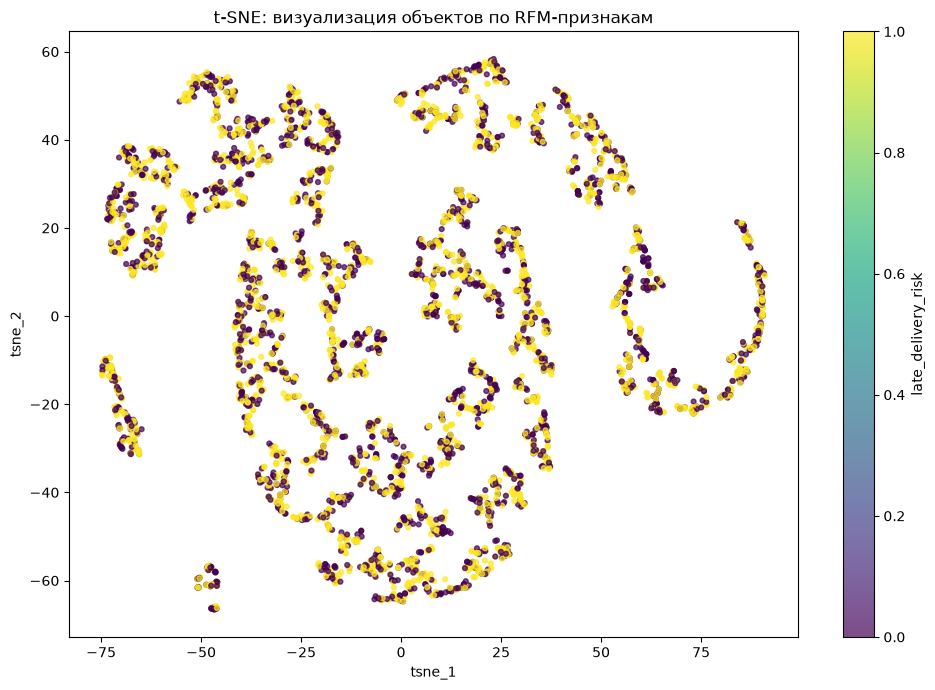

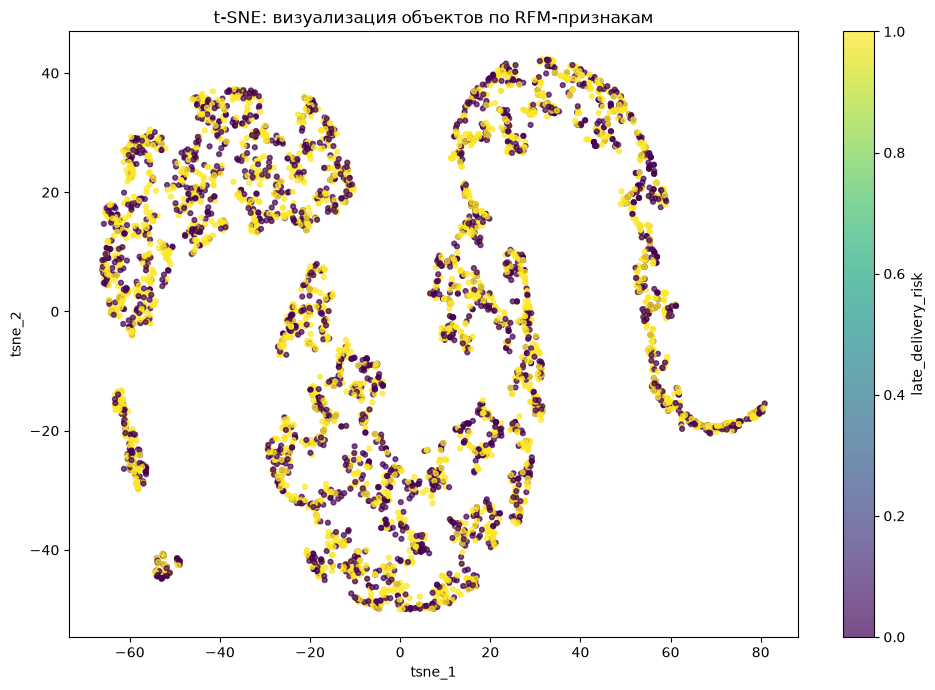

In [59]:
for perp in [10, 30, 50]:
    plot_tsne(df_train, perplexity=perp, features=RFM_FEATURES + [TARGET_COL_NAME], hue=TARGET_COL_NAME)


При раскрашивании точек по целевой переменной, кластеры выгядят как перемешанные и не зависят от таргета. Непосредственное сильное влияние на целевую переменную RFM кластеры не оказывают, но могут давать плезный сигнал совместно с другими признаками. 

<a id="enhanced_model"></a>

##  Обучение модели на новых признаках

Определим пайплайны для обучения на расширенном наборе признаков:

In [60]:

num_features_clustered = [
    'item_price',
    'order_hour',
    'order_weekday',
    'order_month',
    'total_sales',
    'total_orders',
    'recency',
    'avg_discount',
    'return_rate',
    'geo_dist_to_own_center',
    'rfm_dist_to_own_center',
]

# указываем новые кластерные признаки как категории для катбуста, чтобы не было сравнения
cat_features_enhanced = cat_features + [
    'geo_cluster_id',
    'rfm_cluster_id',
]

pipelines = {
    'catboost': {
        'model': pipe(CatBoostClassifier(**DEFAULT_CBM_MODEL_PARAMS)),
        'fit_params' : {
            'model__cat_features': cat_features_enhanced,
            'model__verbose': False
        },
    },
    'logreg': {
        'model': pipe(
            LogisticRegression(**DEFAULT_LOGREG_PARAMS),
            preprocessor=get_preprocessor(num_features_clustered, te_features, ohe_features)),
    },
}

X_train = df_train.drop(columns=cols_to_drop + GEO_FEATURES)
y_train = df_train[TARGET_COL_NAME]
X_val = df_val.drop(columns=cols_to_drop + GEO_FEATURES)
y_val = df_val[TARGET_COL_NAME]


enhanced_metrics = []
for model_name, model_conf in pipelines.items():
    print(f'Обучение модели {model_name}')
    pipeline = model_conf['model']
    fit_params = model_conf.get('fit_params', {})
    if model_name == 'catboost':
        fit_params.update({'model__eval_set': [(X_val, y_val)]})
    wall_time = WallTime()
    pipeline.fit(X_train, y_train, **fit_params)
    elapsed_seconds = wall_time.elapsed_seconds()
    print(f'Модель {model_name} обучена за {elapsed_seconds} секунд')

    y_pred = pipeline.predict(X_val)
    y_pred_proba = pipeline.predict_proba(X_val)
    y_pred_train = pipeline.predict(X_train)
    y_pred_train_proba = pipeline.predict_proba(X_train)
    metrics = calc_all_metrics(model_name, y_val, y_pred, y_pred_proba)
    metrics_train = calc_all_metrics(f'{model_name}_train', y_train, y_pred_train, y_pred_train_proba)
    enhanced_metrics.append(metrics)
    enhanced_metrics.append(metrics_train)

catboost_model = pipelines['catboost']['model'].named_steps['model']
n_iter = catboost_model.best_iteration_

pd.DataFrame(enhanced_metrics).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

Обучение модели catboost
Модель catboost обучена за 3.9769279956817627 секунд
Обучение модели logreg


/Users/ngsmirnov/nikki/projects/practicum/sprint18_catboost_clasterization_bin_classif/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Модель logreg обучена за 0.2213277816772461 секунд


,model,ROC-AUC,Accuracy,Precision,Recall,F1
0,catboost_train,0.795852,0.720749,0.865919,0.581925,0.696069
1,catboost,0.780872,0.723381,0.861559,0.590248,0.700552
2,logreg,0.747920,0.715821,0.859214,0.575992,0.689658
3,logreg_train,0.747622,0.713030,0.862993,0.567934,0.685043


In [61]:
model_train_helper = ModelTrainHelper()
model_train_helper.compare_metrics_df(
    baseline_metrics, enhanced_metrics, 'model == "catboost"', 'ROC-AUC',
    digits=4, pct_digits=2)


Улучшение метрики ROC-AUC: 0.7644->0.7809 (+0.0165/+2.15%)


Целевая метрика CatBoost улучшилась благодаря новым признакам на 2%.

In [62]:
model_train_helper.compare_metrics_df(
    baseline_metrics, enhanced_metrics, 'model == "logreg"', 'ROC-AUC',
    digits=4, pct_digits=2)


Улучшение метрики ROC-AUC: 0.7319->0.7479 (+0.0160/+2.18%)


Целевая метрика LogReg тоже улучшилась благодаря новым признакам на 2% и почти дотягивает до требуемого качества.

<a id="extra"></a>

## Дополнительное задание — подбор лучшего количества кластеров

Подберем оптимальное количество кластеров (гео и rfm) полным перебором для оптимизации целевой метрики.

In [63]:
# Сохраняем базовые датафреймы без кластерных признаков
CLUSTER_COLS = ['geo_cluster_id', 'geo_dist_to_own_center', 'rfm_cluster_id', 'rfm_dist_to_own_center']
df_train_base = df_train.drop(columns=CLUSTER_COLS)
df_val_base   = df_val.drop(columns=CLUSTER_COLS)
df_test_base  = df_test.drop(columns=CLUSTER_COLS)

geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]

best_roc_auc = 0
best_geo_k   = None
best_rfm_k   = None
grid_results = []

for geo_k in geo_k_range:
    for rfm_k in rfm_k_range:
        # кластеризация
        _df_train = df_train_base.copy()
        _df_val   = df_val_base.copy()
        _df_test  = df_test_base.copy()

        _geo_preprocessor = ColumnTransformer([('num', StandardScaler(), GEO_FEATURES)])
        _geo_ch = ClusteringHelper(_df_train, GEO_FEATURES, _geo_preprocessor)
        _df_train, _df_val, _df_test = _geo_ch.fit_make_features(
            geo_k, _df_val, _df_test, features_suffix='geo_')

        _rfm_preprocessor = ColumnTransformer([('num', StandardScaler(), RFM_FEATURES)])
        _rfm_ch = ClusteringHelper(_df_train, RFM_FEATURES, _rfm_preprocessor)
        _df_train, _df_val, _df_test = _rfm_ch.fit_make_features(
            rfm_k, _df_val, _df_test, features_suffix='rfm_')

        # подготовка данных
        X_tr = _df_train.drop(columns=cols_to_drop + GEO_FEATURES)
        y_tr = _df_train[TARGET_COL_NAME]
        X_v  = _df_val.drop(columns=cols_to_drop + GEO_FEATURES)
        y_v  = _df_val[TARGET_COL_NAME]

        # обучение CatBoost
        _model = CatBoostClassifier(**DEFAULT_CBM_MODEL_PARAMS, verbose=False)
        _model.fit(
            X_tr, y_tr,
            cat_features=cat_features,
            eval_set=[(X_v, y_v)]
        )

        # оценка
        y_pred_proba = _model.predict_proba(X_v)[:, 1]
        roc = roc_auc_score(y_v, y_pred_proba)
        grid_results.append({'geo_k': geo_k, 'rfm_k': rfm_k, 'ROC-AUC': round(roc, 4)})
        print(f'geo_k={geo_k:2d}, rfm_k={rfm_k:2d}  →  ROC-AUC={roc:.4f}')

        if roc > best_roc_auc:
            best_roc_auc = roc
            best_geo_k   = geo_k
            best_rfm_k   = rfm_k

print(f'\nЛучший результат: geo_k={best_geo_k}, rfm_k={best_rfm_k},  ROC-AUC={best_roc_auc:.4f}')

# Тепловая карта результатов
grid_df = pd.DataFrame(grid_results).pivot(index='rfm_k', columns='geo_k', values='ROC-AUC')
print('\nТепловая карта ROC-AUC (строки=rfm_k, столбцы=geo_k):')


geo_k= 4, rfm_k= 6  →  ROC-AUC=0.7807
geo_k= 4, rfm_k=12  →  ROC-AUC=0.7818
geo_k= 4, rfm_k=20  →  ROC-AUC=0.7797
geo_k= 4, rfm_k=30  →  ROC-AUC=0.7815
geo_k= 8, rfm_k= 6  →  ROC-AUC=0.7808
geo_k= 8, rfm_k=12  →  ROC-AUC=0.7794
geo_k= 8, rfm_k=20  →  ROC-AUC=0.7798
geo_k= 8, rfm_k=30  →  ROC-AUC=0.7814
geo_k=12, rfm_k= 6  →  ROC-AUC=0.7807
geo_k=12, rfm_k=12  →  ROC-AUC=0.7816
geo_k=12, rfm_k=20  →  ROC-AUC=0.7800
geo_k=12, rfm_k=30  →  ROC-AUC=0.7813
geo_k=20, rfm_k= 6  →  ROC-AUC=0.7810
geo_k=20, rfm_k=12  →  ROC-AUC=0.7805
geo_k=20, rfm_k=20  →  ROC-AUC=0.7798
geo_k=20, rfm_k=30  →  ROC-AUC=0.7813

Лучший результат: geo_k=4, rfm_k=12,  ROC-AUC=0.7818

Тепловая карта ROC-AUC (строки=rfm_k, столбцы=geo_k):


In [64]:
grid_df

geo_k,4,8,12,20
rfm_k,,,,
6,0.7807,0.7808,0.7807,0.7810
12,0.7818,0.7794,0.7816,0.7805
20,0.7797,0.7798,0.7800,0.7798
30,0.7815,0.7814,0.7813,0.7813


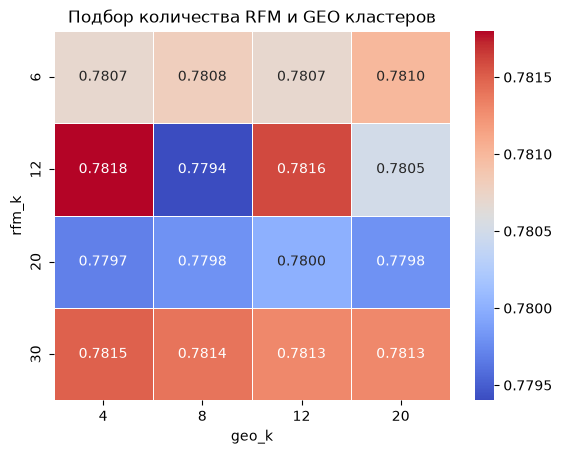

In [65]:
sns.heatmap(grid_df, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.4f')
plt.title('Подбор количества RFM и GEO кластеров')
plt.show()

In [66]:
model_train_helper.compare_metrics(
    pd.DataFrame(enhanced_metrics).query('model == "catboost"')['ROC-AUC'][0],
    best_roc_auc,
    "ROC-AUC"
)

Улучшение метрики ROC-AUC: 0.781->0.782 (+0.001/+0%)


Подбор количества RFM и GEO кластеров увеличивает качество относительно модели с подобранными значениями по методу локтя незначительно, поэтому улучшением можно пренебречь.

<a id="test"></a>

## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

Обучим финальные модели на объединенной выборке train+val, при этом early stopping при обучении CatBoost не используется, будем использовать количество итераций, использованное при последнем обучении.

In [67]:
pipelines = {
    'catboost': {
        'model': pipe(CatBoostClassifier(**DEFAULT_CBM_MODEL_PARAMS | {'iterations': n_iter})),
        'fit_params' : {
            'model__cat_features': cat_features,
            'model__verbose': False
        },
    },
    'logreg': {
        'model': pipe(
            LogisticRegression(**DEFAULT_LOGREG_PARAMS),
            preprocessor=get_preprocessor(num_features_clustered, te_features, ohe_features)),
    },
}

In [68]:
df_train_val = pd.concat([df_train, df_val], axis=0)
X_train_val = df_train_val.drop(columns=cols_to_drop + GEO_FEATURES)
y_train_val = pd.concat([df_train[TARGET_COL_NAME], df_val[TARGET_COL_NAME]], axis=0)

X_test = df_test.drop(columns=cols_to_drop + GEO_FEATURES)
y_test = df_test[TARGET_COL_NAME]

test_metrics = []
for model_name, model_conf in pipelines.items():
    print(f'Обучение модели {model_name}')
    pipeline = model_conf['model']
    fit_params = model_conf.get('fit_params', {})

    wall_time = WallTime()
    pipeline.fit(X_train_val, y_train_val, **fit_params)
    elapsed_seconds = wall_time.elapsed_seconds()
    print(f'Модель {model_name} обучена за {elapsed_seconds} секунд')

    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)
    y_pred_train = pipeline.predict(X_train_val)
    y_pred_proba_train = pipeline.predict_proba(X_train_val)
    metrics = calc_all_metrics(model_name, y_test, y_pred, y_pred_proba)
    metrics_train = calc_all_metrics(f'{model_name}_train', y_train_val, y_pred_train, y_pred_proba_train)
    test_metrics.append(metrics)
    test_metrics.append(metrics_train)

pd.DataFrame(test_metrics).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

Обучение модели catboost
Модель catboost обучена за 0.42098402976989746 секунд
Обучение модели logreg


/Users/ngsmirnov/nikki/projects/practicum/sprint18_catboost_clasterization_bin_classif/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Модель logreg обучена за 0.2878892421722412 секунд


,model,ROC-AUC,Accuracy,Precision,Recall,F1
0,catboost_train,0.816420,0.728955,0.858851,0.606063,0.710647
1,catboost,0.770913,0.715035,0.842028,0.590289,0.694036
2,logreg_train,0.747804,0.711816,0.861887,0.565939,0.683242
3,logreg,0.745266,0.709912,0.857527,0.563873,0.680366


На тестовой выборке модель перформит немного хуже, чем на валидации, но качество удовлетворяет бизнес-требованиям, также заметно переобучение (что ожидаемо, так как мы не подбирали гипер-параметры): CatBoost ROC-AUC = 0.77 

Логистическая регрессия не удовтетворяет требованию ROC-AUC>0.75

Построим матрицу ошибок:

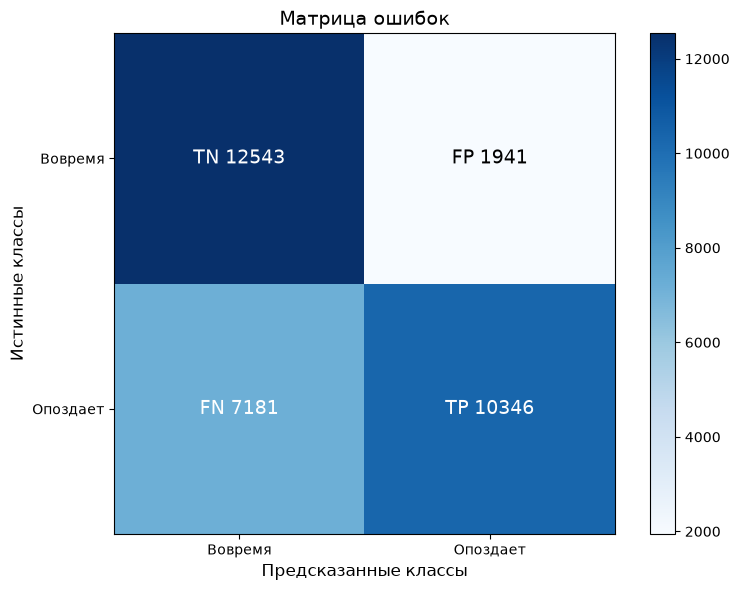

Расшифровка матрицы ошибок:
True Negatives (TN):  12543 - правильно предсказали Вовремя
False Positives (FP): 1941 - ошибочно предсказали Опоздает
False Negatives (FN): 7181 - ошибочно предсказали Вовремя
True Positives (TP):  10346 - правильно предсказали Опоздает


In [69]:
best_model = pipelines['catboost']['model']
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)
model_train_helper.confusion_matrix_displayed(
    y_test, y_pred, true_desc='Опоздает', false_desc='Вовремя'
)


Судя по матрице ошибок модель достаточно часто ошибается предсказывая что заказ будет доставлен вовремя (отрицательный класс), то есть пропускает реальные задержки. Количество ошибок превышает ошибочные предсказания опоздания в ~3.5 раза (FN=7145, FP=2012).

Для улучшения можно предложить подобрать оптимальный порог классификации, вместо дефолтного 0.5.

Оценим вклад признаков в качество модели по SHAP-диаграмме:

/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_86683/4082383751.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, show=False)


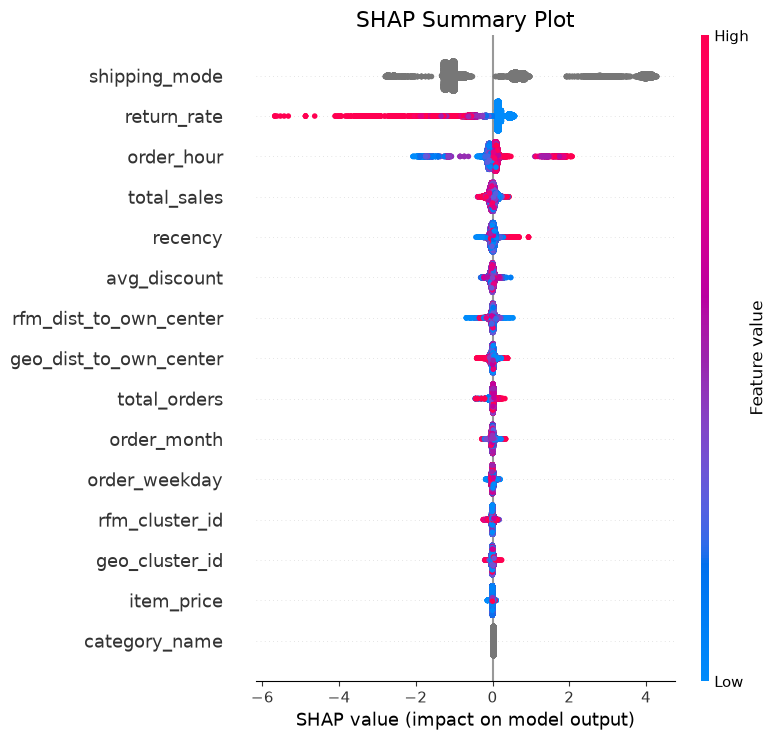

In [70]:
def shap_summary_plot(model, X_val):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_val, show=False)
    plt.title("SHAP Summary Plot", fontsize=16)
    plt.tight_layout()
    plt.show()

shap_summary_plot(best_model.named_steps['model'], X_test)

По важности можно выделить топ признаков:
- shipping_mode (как и было выявлено при корреляционном анализе)
- return_rate (чем меньше доля возвратов у пользователя, тем вероятнее ему опаздывает доставка - возможно так отрабатывают обратную связь отдел удовлетворенности клиентов и часто возвращающим клиентам улучшаю доставку)
- час заказа тоже имеет влияние - чем больше час заказа, тем больше вероятность опаздывания доставки - вероятно сроки переносятся из-за позднего заказа. (в этом случае рекомендуется указывать клиенту, что его заказ будет доставлен позже, чем если он заказывает до завершения операционного дня)
- на 4 месте rfm_dist_to_own_center - можно только отметить, что новый признак после кластеризации входит в топ4.
- на 6 месте geo_dist_to_own_center, тоже полезный признак
- маркеры признаков на 10 и 11 местах - мало полезные признаки как таковые.

<a id="conclusion"></a>

##  Выводы и рекомендации

**Результаты моделирования.** CatBoost показал ROC-AUC=0.7738 на тестовой выборке - бизнес-требование >0.75 выполнено. Логрег требование не выполняет (0.745). Небольшое переобучение есть (train 0.82 vs test 0.77), что ожидаемо при фиксированных гиперпараметрах.

**Эффективность сегментации.** Гипотеза подтвердилась: оба типа кластеризации дали полезные признаки. rfm_dist_to_own_center занял 4-е место по SHAP-важности, geo_dist_to_own_center - 6-е. Поведенческие (RFM) признаки оказались чуть информативнее географических. Интересный инсайт - кластеры в чистом виде почти не дают улучшения, а производные от них (расстояние до центройда) полезнее.

**Технический инсайт.** Оптимальное сочетание гиперпараметров кластеризации: rfm_k=12, geo_k=4 (ROC-AUC на валидации 0.7818). Но подбор параметров по методу локтя rfm_k=7, geo_k=4 уже дает близкое к оптимальному решение. Перебор менял ROC-AUC только в тысячных.

**Бизнес-рекомендации.** Модель готова к внедрению в операционный процесс CargaPronto. Рекомендуется снизить порог классификации с дефолтных 0.5 - модель пропускает задержки в ~3.5 раза чаще, чем ложно сигналит (FN=7145 vs FP=2012), то есть выгоднее ловить больше реальных задержек ценой роста ложных тревог. Дополнительно стоит проанализировать кластеры с наибольшей долей задержек и отработать для них отдельные операционные решения.